Author: Soubhik Majumdar

# With 2D planar RIS

# RIS Channel Simulation — Variable Explanation (2D Planar Panel)

---

## System Parameters

| Variable | Code | Meaning |
|---|---|---|
| $N_y$ | `Ny` | Number of RIS elements vertically (rows). Controls elevation beamforming resolution |
| $N_z$ | `Nz` | Number of RIS elements horizontally (columns). Controls azimuth beamforming resolution |
| $N = N_y \times N_z$ | `N` | Total number of RIS elements. Maximum achievable gain $\propto N^2$ |
| $f_c$ | `fc` | Carrier frequency [Hz]. Higher $f_c$ → shorter wavelength → smaller elements → larger free-space path loss |
| $c$ | `c` | Speed of light = $3 \times 10^8$ m/s |
| $\lambda = c/f_c$ | `lam` | Wavelength [m] |
| $d_\text{elem} = \lambda/2$ | `d_elem` | Half-wavelength element spacing [m] — avoids grating lobes, scales automatically with $f_c$ |

---

## 3D Geometry

Coordinates follow the convention: **x = depth** (TX–RIS–RX axis), **y = vertical** (height), **z = lateral** (side-to-side).

| Variable | Code | Meaning |
|---|---|---|
| `tx_pos` | `tx_pos` | Transmitter position $(x, y, z)$ [m] |
| `rx_pos` | `rx_pos` | Receiver position $(x, y, z)$ [m]. Direct path length $d_d = \|\text{rx\_pos} - \text{tx\_pos}\|_2$ |
| `ris_x` | `ris_x` | Depth (x-coordinate) of the RIS panel wall [m] |
| `ris_y_ctr` | `ris_y_ctr` | Vertical centre of the panel [m] — e.g. mounting height on a wall |
| `ris_z_ctr` | `ris_z_ctr` | Lateral centre of the panel [m] |

### Panel Element Positions

Elements are indexed as $(m, k)$ where $m \in [0, N_y)$ is the row (vertical) and $k \in [0, N_z)$ is the column (horizontal). Flat index $n = m \cdot N_z + k$.

```python
y_offsets = (arange(Ny) - (Ny-1)/2) * d_elem + ris_y_ctr   # (Ny,)  vertical centres
z_offsets = (arange(Nz) - (Nz-1)/2) * d_elem + ris_z_ctr   # (Nz,)  horizontal centres
YY, ZZ   = meshgrid(y_offsets, z_offsets, indexing='ij')    # (Ny, Nz)
ris_pos  = stack([XX, YY, ZZ], axis=-1).reshape(N, 3)       # (N, 3)
```

| Variable | Code | Meaning |
|---|---|---|
| `y_offsets` | `y_offsets` | y-coordinate of each row centre [m]. Shape $(N_y,)$ |
| `z_offsets` | `z_offsets` | z-coordinate of each column centre [m]. Shape $(N_z,)$ |
| `YY, ZZ` | `YY, ZZ` | 2D meshgrid of element positions on the panel. Shape $(N_y, N_z)$ |
| `ris_pos` | `ris_pos` | 3D position of every element. Shape $(N, 3)$ — row-major flatten of the $(N_y, N_z)$ grid |

---

## Distances

| Variable | Code | Formula | Meaning |
|---|---|---|---|
| $d_{n,a}$ | `d_a` | $\|\text{ris\_pos}[n] - \text{tx\_pos}\|_2$ | Distance TX → element $n$ [m]. Shape $(N,)$ |
| $d_{n,b}$ | `d_b` | $\|\text{ris\_pos}[n] - \text{rx\_pos}\|_2$ | Distance element $n$ → RX [m]. Shape $(N,)$ |
| $d_d$ | `d_d` | $\|\text{rx\_pos} - \text{tx\_pos}\|_2$ | Direct TX → RX distance [m]. Scalar |

In the 2D panel, $d_{n,a}$ and $d_{n,b}$ vary across both rows and columns, producing a 2D phase pattern on the panel rather than a 1D curve.

---

## Propagation Delays

| Variable | Code | Formula | Meaning |
|---|---|---|---|
| $\tau_{n,a}$ | `tau_na` | $d_{n,a}/c$ | TX → element $n$ propagation delay [s]. Shape $(N,)$ |
| $\tau_{n,b}$ | `tau_nb` | $d_{n,b}/c$ | Element $n$ → RX propagation delay [s]. Shape $(N,)$ |
| $\tau_d$ | `tau_d` | $d_d/c$ | Direct TX → RX propagation delay [s]. Scalar |
| $\tau_{\theta_n}$ | `tau_theta` | **controllable** | Delay added by the RIS controller at element $n$. This is what the agent learns to optimise. Shape $(N,)$ |

---

## Path Attenuations (Power)

| Variable | Code | Formula | Meaning |
|---|---|---|---|
| $\alpha_n$ | `alpha` | $\left(\frac{\lambda}{4\pi d_{n,a}}\right)^2$ | Free-space power loss TX → element $n$. Shape $(N,)$ |
| $\beta_n$ | `beta` | $\left(\frac{\lambda}{4\pi d_{n,b}}\right)^2$ | Free-space power loss element $n$ → RX. Shape $(N,)$ |
| $\rho$ | `rho` | $\left(\frac{\lambda}{4\pi d_d}\right)^2$ | Direct path power loss. Scalar. Set to 0 when `include_direct=False` |

### Element Reflection Efficiency $\gamma_n$

| `gamma_mode` | Description |
|---|---|
| `'ideal'` | $\gamma_n = 1$ for all $n$ — perfect elements |
| `'random'` | $\gamma_n \sim \mathcal{U}(0.8, 1.0)$ — ±10% manufacturing variation |
| `'faulty'` | $\gamma_n = 0$ for a random fraction `faulty_frac` of elements — dead patches |
| `'taper'` | $\gamma_n = 0.7 + 0.3 \cdot w_n$ where $w_n$ is the 2D Hanning window $w_y[m] \cdot w_z[k]$ — tapered aperture to reduce sidelobes |

For the 2D `'taper'` mode, the window is computed as the outer product of two 1D Hanning windows:
```python
taper_2d = outer(hanning(Ny), hanning(Nz)).ravel()   # (N,)
gamma    = 0.7 + 0.3 * taper_2d
```

The combined reflected amplitude of element $n$ is $\sqrt{\alpha_n \beta_n \gamma_n}$ (square root because attenuations are power quantities; the signal model works in amplitude).

---

## The Received Signal

$$y = \underbrace{\sqrt{\rho}\,e^{-j2\pi f_c \tau_d}}_{\text{direct path (Case 1 only)}} + \underbrace{\sum_{n=0}^{N-1} \sqrt{\alpha_n\beta_n\gamma_n}\,e^{-j2\pi f_c(\tau_{n,a} + \tau_{\theta_n} + \tau_{n,b})}}_{\text{N reflected paths via 2D RIS panel}}$$

For constructive interference all $N$ phasors must point in the same complex direction. The channel gain is:

$$|h|^2 \leq \left(\sqrt{\rho} + \sum_{n=0}^{N-1}\sqrt{\alpha_n\beta_n\gamma_n}\right)^2 \approx N^2\bar{\alpha}\bar{\beta}\bar{\gamma} \quad \text{(upper bound, grows as } N^2\text{)}$$

With a 2D panel, $N = N_y N_z$, so doubling both dimensions quadruples the gain — a stronger scaling argument than a 1D array of the same total element count.

---

## Optimal Phase — 2D Panel

The phase optimisation is performed element-by-element on the flattened array (shape $(N,)$), then reshaped to the 2D panel for display:

```python
phi_panel = phi_opt_wrapped.reshape(Ny, Nz)   # (Ny, Nz) — for heatmap plots
```

Because $d_{n,a}$ and $d_{n,b}$ vary across both rows and columns (TX and RX are generally offset in all three dimensions), the optimal phase pattern is a **2D surface** on the panel, not a simple row-only or column-only gradient.

### `tau_theta_opt_direct` — Case 1: WITH direct path

$$\tau_{\theta_n}^* = \left(\tau_d - \tau_{n,a} - \tau_{n,b}\right) \bmod \frac{1}{f_c}$$

Aligns every reflected phasor with the direct-path phasor. The modulo wraps negative raw delays into $[0, 1/f_c)$ without disturbing phase alignment, since adding $k/f_c$ shifts phase by $2\pi k$ (invisible at frequency $f_c$).

### `tau_theta_opt_nodirect` — Case 2: WITHOUT direct path

$$\tau_{\theta_n}^* = \max_m\!\left(\tau_{m,a} + \tau_{m,b}\right) - \left(\tau_{n,a} + \tau_{n,b}\right)$$

No external reference exists, so the element with the **longest geometric path** becomes the reference. All other elements add delay to match it, making all $N$ signals arrive simultaneously at RX.

### Which case is used?

```python
tau_theta_opt = tau_theta_opt_direct if include_direct else tau_theta_opt_nodirect
```

| Condition | Valid case |
|---|---|
| `include_direct = True` (LOS) | Case 1 — modulo-wrapped, may have phase discontinuities across panel |
| `include_direct = False` (NLOS) | Case 2 — smooth, monotone across panel |

---

## Phase Wrapping for Display

The raw unwrapped phase can exceed ±180°. For display and for programming a real RIS controller:

```python
phi_opt_deg     = rad2deg(2 * pi * fc * tau_theta_opt)     # unwrapped [°], shape (N,)
phi_opt_wrapped = ((phi_opt_deg + 180) % 360) - 180        # wrapped to ±180°, shape (N,)
phi_panel       = phi_opt_wrapped.reshape(Ny, Nz)          # 2D panel grid (Ny, Nz)
```

The wrapped values are what a real RIS hardware controller programs into each element. The cyclic (`twilight_shifted`) colormap used in Plot 2 is chosen specifically because it wraps at ±180°, making phase discontinuities visually natural rather than misleading.

---

## Plots

| Plot | Type | What it shows |
|---|---|---|
| **Plot 1** | Interactive 3D (Plotly) | TX, RX, and 2D RIS panel in 3D space. Elements coloured by $\phi_n^*$. Sample rays show selected TX→element→RX paths. Drag to rotate, hover for per-element phase. Saved as `.html` |
| **Plot 2** | 2D heatmap (Matplotlib) | $\phi_n^*$ on the $(N_y \times N_z)$ panel using cyclic `twilight_shifted` colormap, ±180° wrapped. Element grid overlay. Min/max elements annotated |
| **Plot 3** | Phasor diagram | Unit-normalised complex phasors for a sample of elements — random (scattered, tomato) vs optimal (aligned, blue). Visually demonstrates constructive interference |
| **Plot 4** | Line plot | Channel gain [dB] vs number of active elements $n$, filled row-by-row through the panel. Compares optimal $\tau^*$, random delays, and upper bound. Vertical lines mark row boundaries |

---

## Summary: What the CQL Agent Must Rediscover

`tau_theta_opt` (equivalently `phi_panel`) is the ground-truth optimum derived analytically from geometry. The CQL/DQN agent receives only the state (channel features) and a scalar reward (SNR or rate) — it must learn to reproduce this 2D phase pattern purely through offline Q-value optimisation, without ever being given the formula above.

System Setup
  Carrier frequency : 28.0 GHz  |  λ = 1.07 cm
  Panel size        : 16×16 = 256 elements
  Panel aperture    : 8.6 cm (H) × 8.6 cm (W)
  Element quality   : ideal
  Direct path       : no (NLOS)

Optimal Phase
  Wrapped range : [-179.6°, 179.9°]

Channel Gain
  Upper bound  : -130.70 dB
  Optimal τ*   : -130.70 dB
  Zero delays  : -146.09 dB
  Random       : -158.64 dB



Interactive geometry saved → /content/ris_geometry_interactive.html


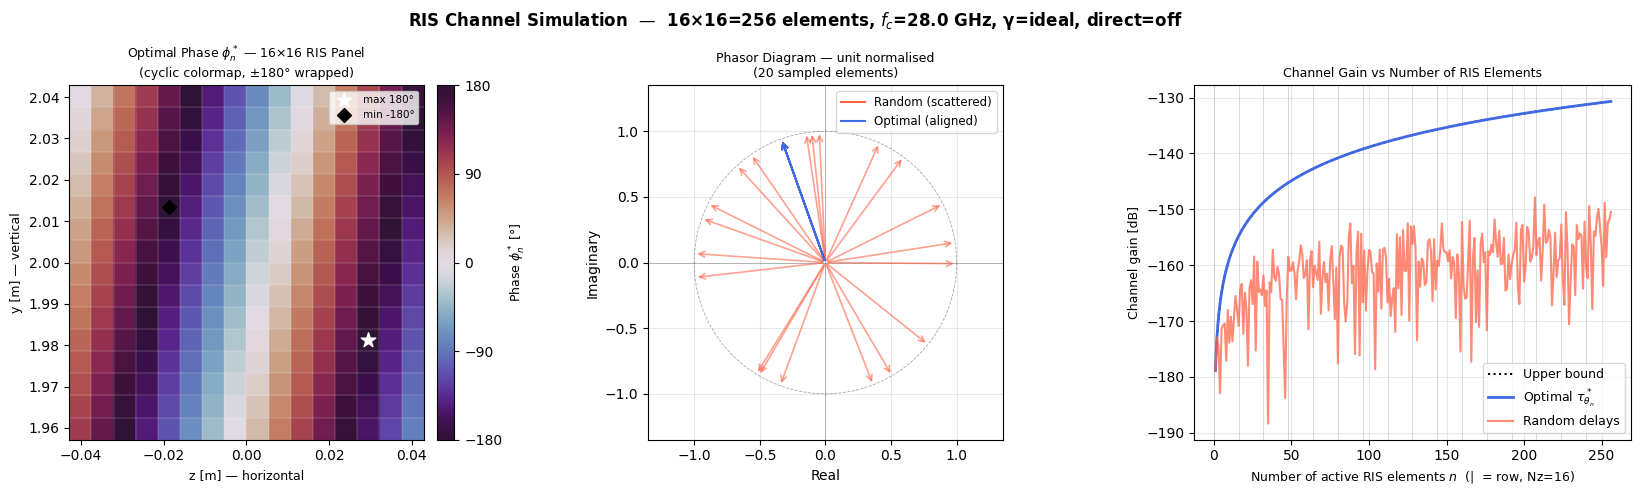

Done. Plots saved to /content/


In [ ]:
"""
RIS Channel Simulation — Narrowband Model (2D Planar Panel)
============================================================
Google Colab version

Plot 1: Interactive 3D geometry  (Plotly)
Plot 2: 2D phase heatmap on panel (Matplotlib)
Plot 3: Phasor diagram            (Matplotlib)
Plot 4: Channel gain vs N         (Matplotlib)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("Plotly not found — pip install plotly  for interactive geometry plot")

# ═══════════════════════════════════════════════════════════════════
# PARAMETERS
# ═══════════════════════════════════════════════════════════════════

# --- RIS panel dimensions ---
Ny = 16             # elements vertically   (rows)
Nz = 16             # elements horizontally (columns)
N  = Ny * Nz        # total elements

# --- Radio ---
fc  = 28e9          # carrier frequency [Hz]

# --- 3D Positions [metres]  (x=depth, y=vertical, z=lateral) ---
tx_pos = np.array([0.0,  1.5,  0.0])
rx_pos = np.array([50.0, 1.5,  5.0])

# RIS panel centre (mounted on wall at x = ris_x)
ris_x     = 25.0    # depth [m]
ris_y_ctr = 2.0     # height centre [m]
ris_z_ctr = 0.0     # lateral centre [m]

# --- RIS element quality ---
gamma_mode  = 'ideal'   # 'ideal' | 'random' | 'faulty' | 'taper'
faulty_frac = 0.05

# --- Direct path ---
include_direct = False

# --- Simulation ---
random_seed = 42

# ═══════════════════════════════════════════════════════════════════
# DERIVED CONSTANTS
# ═══════════════════════════════════════════════════════════════════

np.random.seed(random_seed)
c       = 3e8
lam     = c / fc
d_elem  = lam / 2

# ─────────────────────────────────────────────
# 2D PANEL GEOMETRY  →  element positions (N, 3)
# ─────────────────────────────────────────────
y_offsets = (np.arange(Ny) - (Ny - 1) / 2) * d_elem + ris_y_ctr
z_offsets = (np.arange(Nz) - (Nz - 1) / 2) * d_elem + ris_z_ctr

YY, ZZ = np.meshgrid(y_offsets, z_offsets, indexing='ij')   # (Ny, Nz)
XX     = np.full_like(YY, ris_x)

ris_pos = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=1)  # (N, 3)

array_length = max(Ny, Nz) * d_elem   # largest aperture dimension

print("System Setup")
print(f"  Carrier frequency : {fc/1e9:.1f} GHz  |  λ = {lam*100:.2f} cm")
print(f"  Panel size        : {Ny}×{Nz} = {N} elements")
print(f"  Panel aperture    : {Ny*d_elem*100:.1f} cm (H) × {Nz*d_elem*100:.1f} cm (W)")
print(f"  Element quality   : {gamma_mode}")
print(f"  Direct path       : {'yes' if include_direct else 'no (NLOS)'}\n")

# Near-field warning
d_nearfield    = 2 * array_length**2 / lam
d_tx_to_center = np.linalg.norm(tx_pos - np.array([ris_x, ris_y_ctr, ris_z_ctr]))
if d_tx_to_center < d_nearfield:
    print(f"  ⚠ Near-field: TX {d_tx_to_center:.1f} m from panel, boundary = {d_nearfield:.1f} m\n")

# ─────────────────────────────────────────────
# CHANNEL PARAMETERS
# ─────────────────────────────────────────────

def path_loss(d):
    return (lam / (4 * np.pi * d)) ** 2

d_a = np.linalg.norm(ris_pos - tx_pos, axis=1)   # (N,)
d_b = np.linalg.norm(ris_pos - rx_pos, axis=1)   # (N,)
d_d = np.linalg.norm(rx_pos  - tx_pos)

tau_na = d_a / c
tau_nb = d_b / c
tau_d  = d_d / c

alpha  = path_loss(d_a)
beta   = path_loss(d_b)
rho    = path_loss(d_d) if include_direct else 0.0

if gamma_mode == 'ideal':
    gamma = np.ones(N)
elif gamma_mode == 'random':
    gamma = np.random.uniform(0.8, 1.0, N)
elif gamma_mode == 'faulty':
    gamma = np.ones(N)
    idx_f = np.random.choice(N, int(faulty_frac * N), replace=False)
    gamma[idx_f] = 0.0
elif gamma_mode == 'taper':
    taper_2d = np.outer(np.hanning(Ny), np.hanning(Nz)).ravel()
    gamma    = 0.7 + 0.3 * taper_2d
else:
    raise ValueError(f"Unknown gamma_mode: {gamma_mode}")

# ─────────────────────────────────────────────
# OPTIMAL DELAYS & PHASE
# ─────────────────────────────────────────────

tau_theta_opt_direct   = (tau_d - tau_na - tau_nb) % (1 / fc)
tau_geo                = tau_na + tau_nb
tau_theta_opt_nodirect = tau_geo.max() - tau_geo

tau_theta_opt = tau_theta_opt_direct if include_direct else tau_theta_opt_nodirect

# Phase in degrees, wrapped to ±180°
phi_opt_deg     = np.rad2deg(2 * np.pi * fc * tau_theta_opt)
phi_opt_wrapped = ((phi_opt_deg + 180) % 360) - 180           # (N,)
phi_panel       = phi_opt_wrapped.reshape(Ny, Nz)             # (Ny, Nz)

print(f"Optimal Phase")
print(f"  Wrapped range : [{phi_opt_wrapped.min():.1f}°, {phi_opt_wrapped.max():.1f}°]\n")

# ─────────────────────────────────────────────
# CHANNEL GAIN
# ─────────────────────────────────────────────

def channel_gain(tau_theta, use_direct=include_direct):
    n       = len(tau_theta)
    amp     = np.sqrt(alpha[:n] * beta[:n] * gamma[:n])
    phasors = amp * np.exp(-1j * 2*np.pi*fc * (tau_na[:n] + tau_theta + tau_nb[:n]))
    h_ris   = phasors.sum()
    if use_direct:
        h_dir = np.sqrt(rho) * np.exp(-1j * 2*np.pi*fc * tau_d)
        return np.abs(h_dir + h_ris) ** 2
    return np.abs(h_ris) ** 2

upper_bound  = (np.sqrt(rho) + np.sum(np.sqrt(alpha * beta * gamma))) ** 2
gain_optimal = channel_gain(tau_theta_opt)
gain_random  = channel_gain(np.random.uniform(0, 1/fc, N))
gain_zero    = channel_gain(np.zeros(N))

print("Channel Gain")
print(f"  Upper bound  : {10*np.log10(upper_bound):.2f} dB")
print(f"  Optimal τ*   : {10*np.log10(gain_optimal):.2f} dB")
print(f"  Zero delays  : {10*np.log10(gain_zero):.2f} dB")
print(f"  Random       : {10*np.log10(gain_random):.2f} dB\n")

# ═══════════════════════════════════════════════════════════════════
# PLOT 1 — Interactive 3D Geometry  (Plotly)
# ═══════════════════════════════════════════════════════════════════

if HAS_PLOTLY:
    fig_geo = go.Figure()

    # RIS panel elements — colour by phase
    fig_geo.add_trace(go.Scatter3d(
        x=ris_pos[:, 0], y=ris_pos[:, 2], z=ris_pos[:, 1],
        mode='markers',
        marker=dict(
            size=4,
            color=phi_opt_wrapped,
            colorscale='twilight',
            cmin=-180, cmax=180,
            colorbar=dict(title='φ* [°]', tickvals=[-180,-90,0,90,180]),
            showscale=True,
        ),
        name='RIS elements (coloured by φ*)',
        hovertemplate='x=%{x:.2f} m<br>z=%{y:.2f} m<br>y=%{z:.2f} m<br>φ=%{marker.color:.1f}°<extra></extra>'
    ))

    # TX
    fig_geo.add_trace(go.Scatter3d(
        x=[tx_pos[0]], y=[tx_pos[2]], z=[tx_pos[1]],
        mode='markers+text',
        marker=dict(size=10, color='royalblue', symbol='diamond'),
        text=['TX'], textposition='top center',
        name='TX'
    ))

    # RX
    fig_geo.add_trace(go.Scatter3d(
        x=[rx_pos[0]], y=[rx_pos[2]], z=[rx_pos[1]],
        mode='markers+text',
        marker=dict(size=10, color='seagreen', symbol='circle'),
        text=['RX'], textposition='top center',
        name='RX'
    ))

    # Sample rays: TX → 5 panel corners/centre → RX
    corner_indices = [0, Nz-1, N-Nz, N-1, N//2]
    for ci in corner_indices:
        ex, ey, ez = ris_pos[ci]
        fig_geo.add_trace(go.Scatter3d(
            x=[tx_pos[0], ex, rx_pos[0]],
            y=[tx_pos[2], ez, rx_pos[2]],
            z=[tx_pos[1], ey, rx_pos[1]],
            mode='lines',
            line=dict(color='tomato', width=2, dash='dash'),
            showlegend=False, opacity=0.5
        ))

    # Direct path
    if include_direct:
        fig_geo.add_trace(go.Scatter3d(
            x=[tx_pos[0], rx_pos[0]],
            y=[tx_pos[2], rx_pos[2]],
            z=[tx_pos[1], rx_pos[1]],
            mode='lines',
            line=dict(color='royalblue', width=3),
            name='Direct path'
        ))

    fig_geo.update_layout(
        title=dict(
            text=f"RIS 3D Geometry — {Ny}×{Nz} panel, fc={fc/1e9:.0f} GHz<br>"
                 f"<sup>Elements coloured by optimal phase φ* | Drag to rotate</sup>",
            x=0.5, font=dict(size=14)
        ),
        scene=dict(
            xaxis_title='x [m] — depth',
            yaxis_title='z [m] — lateral',
            zaxis_title='y [m] — height',
            aspectmode='manual',
            aspectratio=dict(x=2.5, y=0.8, z=0.5),
            camera=dict(eye=dict(x=1.5, y=-1.8, z=0.8))
        ),
        legend=dict(x=0.01, y=0.99),
        width=900, height=550,
        margin=dict(l=0, r=0, t=80, b=0)
    )
    fig_geo.show()
    fig_geo.write_html('/content/ris_geometry_interactive.html')
    print("Interactive geometry saved → /content/ris_geometry_interactive.html")

# ═══════════════════════════════════════════════════════════════════
# PLOTS 2–4 — Matplotlib  (2×2 minus top-left → 1 row + 2 row)
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f"RIS Channel Simulation  —  {Ny}×{Nz}={N} elements, "
    f"$f_c$={fc/1e9:.1f} GHz, γ={gamma_mode}, "
    f"direct={'on' if include_direct else 'off'}",
    fontsize=12, fontweight='bold'
)

# ── Plot 2: 2D Phase Heatmap ──────────────────────────────────────────────────
ax2 = axes[0]

extent_panel = [z_offsets[0] - d_elem/2, z_offsets[-1] + d_elem/2,
                y_offsets[0] - d_elem/2, y_offsets[-1] + d_elem/2]

im = ax2.imshow(phi_panel, cmap='twilight_shifted', vmin=-180, vmax=180,
                origin='lower', extent=extent_panel, aspect='equal',
                interpolation='nearest')

# Grid lines between elements
for z in z_offsets[:-1] + d_elem/2:
    ax2.axvline(z, color='white', linewidth=0.3, alpha=0.5)
for y in y_offsets[:-1] + d_elem/2:
    ax2.axhline(y, color='white', linewidth=0.3, alpha=0.5)

cb = plt.colorbar(im, ax=ax2, pad=0.03, fraction=0.046)
cb.set_label('Phase $\\phi_n^*$ [°]', fontsize=9)
cb.set_ticks([-180, -90, 0, 90, 180])

# Annotate min/max
idx_mx = np.unravel_index(np.argmax(phi_panel), phi_panel.shape)
idx_mn = np.unravel_index(np.argmin(phi_panel), phi_panel.shape)
ax2.scatter(z_offsets[idx_mx[1]], y_offsets[idx_mx[0]],
            marker='*', s=120, color='white', zorder=5, label=f'max {phi_panel.max():.0f}°')
ax2.scatter(z_offsets[idx_mn[1]], y_offsets[idx_mn[0]],
            marker='D', s=50, color='black', zorder=5, label=f'min {phi_panel.min():.0f}°')
ax2.legend(fontsize=7.5, loc='upper right')

ax2.set_xlabel('z [m] — horizontal', fontsize=9)
ax2.set_ylabel('y [m] — vertical', fontsize=9)
ax2.set_title(f'Optimal Phase $\\phi_n^*$ — {Ny}×{Nz} RIS Panel\n'
              f'(cyclic colormap, ±180° wrapped)', fontsize=9)

# ── Plot 3: Phasor Diagram ────────────────────────────────────────────────────
ax3 = axes[1]

n_phasors = 20
idx_s     = np.linspace(0, N-1, n_phasors, dtype=int)

phase_rand = -2*np.pi*fc*(tau_na[idx_s] + np.random.uniform(0, 1/fc, n_phasors) + tau_nb[idx_s])
phase_opt  = -2*np.pi*fc*(tau_na[idx_s] + tau_theta_opt[idx_s] + tau_nb[idx_s])

for p in np.exp(1j * phase_rand):
    ax3.annotate('', xy=(p.real, p.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='tomato', lw=1.2, alpha=0.6))
for p in np.exp(1j * phase_opt):
    ax3.annotate('', xy=(p.real, p.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.2, alpha=0.6))

theta_c = np.linspace(0, 2*np.pi, 300)
ax3.plot(np.cos(theta_c), np.sin(theta_c), 'k--', linewidth=0.6, alpha=0.35)
ax3.axhline(0, color='k', linewidth=0.4, alpha=0.4)
ax3.axvline(0, color='k', linewidth=0.4, alpha=0.4)
ax3.set_xlim(-1.35, 1.35); ax3.set_ylim(-1.35, 1.35)
ax3.set_aspect('equal')

ax3.legend(handles=[
    Line2D([0],[0], color='tomato',    label='Random (scattered)'),
    Line2D([0],[0], color='royalblue', label='Optimal (aligned)'),
], fontsize=8.5)
ax3.set_xlabel('Real'); ax3.set_ylabel('Imaginary')
ax3.set_title(f'Phasor Diagram — unit normalised\n({n_phasors} sampled elements)', fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Plot 4: Channel Gain vs N ─────────────────────────────────────────────────
ax4 = axes[2]

step      = max(1, N // 200)
n_vals    = np.arange(1, N+1, step)
gains_opt  = []
gains_rand = []
ub_vals    = []

for n in n_vals:
    gains_opt.append (10*np.log10(channel_gain(tau_theta_opt[:n])))
    gains_rand.append(10*np.log10(channel_gain(np.random.uniform(0, 1/fc, n))))
    ub = (np.sqrt(rho) + np.sum(np.sqrt(alpha[:n]*beta[:n]*gamma[:n])))**2
    ub_vals.append(10*np.log10(ub))

# Mark row boundaries
for row_start in range(0, N, Nz):
    ax4.axvline(row_start, color='lightgray', linewidth=0.6, zorder=0)

ax4.plot(n_vals, ub_vals,    color='black',      linestyle=':', lw=1.5, label='Upper bound')
ax4.plot(n_vals, gains_opt,  color='royalblue',                lw=2.0, label=r'Optimal $\tau_{\theta_n}^*$')
ax4.plot(n_vals, gains_rand, color='tomato', alpha=0.75,       lw=1.5, label='Random delays')

ax4.set_xlabel(f'Number of active RIS elements $n$  (|  = row, Nz={Nz})', fontsize=9)
ax4.set_ylabel('Channel gain [dB]', fontsize=9)
ax4.set_title('Channel Gain vs Number of RIS Elements', fontsize=9)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/ris_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done. Plots saved to /content/")

### RIS Simulation

RIS Panel
  Elements       : 16 × 16 = 256
  Frequency      : 28 GHz
  Wavelength     : 10.71 mm
  Element spacing: 5.36 mm  (λ/2)
  Panel size     : 8.6 cm × 8.6 cm
  Panel centre   : x=25.0m  y=2.0m  z=0.0m

Sanity Check  (fixed geometry)
  TX : [2.  1.5 0. ]
  RX : [50.   1.5  3. ]
  Gain — optimal  : -129.86 dB
  Gain — zeros    : -157.48 dB
  Gain — random   : -154.41 dB
  Headroom        : 24.54 dB  (optimal vs random)



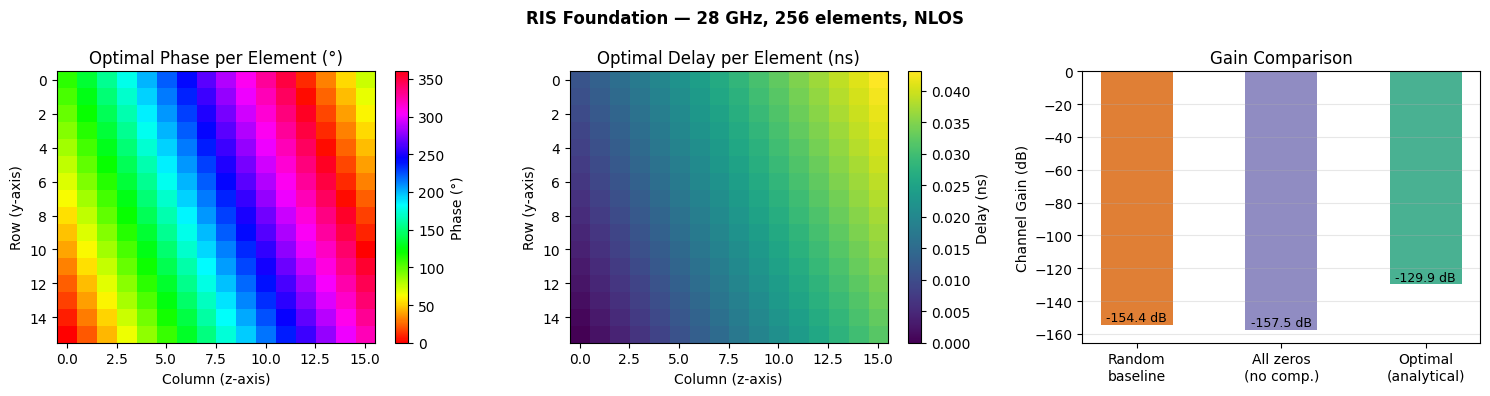

Foundation ready.
  ris_pos        : (256, 3)  element positions
  compute_channel: tx, rx → tau_opt, phi_opt, gain_opt
  channel_gain   : tau_theta → |h|²
  random_gain    : → baseline for reward normalisation

Next block: action space + multi-step environment


In [ ]:
"""
RIS SIMULATION — FOUNDATION
============================
Block 1 of 4. Run this first.

Sets up:
  - RIS panel geometry (16×16, 28 GHz)
  - Channel model (free-space path loss, NLOS)
  - Core gain computation
  - Analytical optimal as upper bound reference

Everything downstream (environment, dataset, RL) builds on this.
"""

import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════
# CONSTANTS
# ═══════════════════════════════════════════════════════════════════

c   = 3e8           # speed of light [m/s]
fc  = 28e9          # carrier frequency [Hz]  (28 GHz mmWave)
lam = c / fc        # wavelength [m]

# ═══════════════════════════════════════════════════════════════════
# RIS PANEL
# ═══════════════════════════════════════════════════════════════════

Ny = 16             # rows    (vertical)
Nz = 16             # columns (lateral)
N  = Ny * Nz        # 256 elements total

d_elem = lam / 2    # half-wavelength element spacing

# Panel centre — mounted on wall
ris_x   = 25.0      # depth [m]
ris_y   = 2.0       # height [m]
ris_z   = 0.0       # lateral [m]

# Build element positions (N, 3)
y_pos = (np.arange(Ny) - (Ny - 1) / 2) * d_elem + ris_y
z_pos = (np.arange(Nz) - (Nz - 1) / 2) * d_elem + ris_z
YY, ZZ = np.meshgrid(y_pos, z_pos, indexing='ij')
XX = np.full_like(YY, ris_x)
ris_pos = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=1)  # (N, 3)

print(f"RIS Panel")
print(f"  Elements       : {Ny} × {Nz} = {N}")
print(f"  Frequency      : {fc/1e9:.0f} GHz")
print(f"  Wavelength     : {lam*1000:.2f} mm")
print(f"  Element spacing: {d_elem*1000:.2f} mm  (λ/2)")
print(f"  Panel size     : {Ny*d_elem*100:.1f} cm × {Nz*d_elem*100:.1f} cm")
print(f"  Panel centre   : x={ris_x}m  y={ris_y}m  z={ris_z}m\n")

# ═══════════════════════════════════════════════════════════════════
# CHANNEL MODEL
# ═══════════════════════════════════════════════════════════════════

def compute_channel(tx, rx):
    """
    Compute channel parameters for given TX and RX positions.

    Returns
    -------
    tau_na      : (N,) propagation delay TX → element n [s]
    tau_nb      : (N,) propagation delay element n → RX [s]
    alpha       : (N,) path loss TX → element n
    beta        : (N,) path loss element n → RX
    tau_opt     : (N,) optimal delay per element [s]
    phi_opt_deg : (N,) optimal phase per element [degrees]
    gain_opt    : float, channel gain under optimal configuration
    """
    d_a = np.linalg.norm(ris_pos - tx, axis=1)   # (N,) TX-element distances
    d_b = np.linalg.norm(ris_pos - rx, axis=1)   # (N,) element-RX distances

    tau_na = d_a / c
    tau_nb = d_b / c
    alpha  = (lam / (4 * np.pi * d_a)) ** 2
    beta   = (lam / (4 * np.pi * d_b)) ** 2

    # NLOS optimal: align all element phasors to be in phase at RX
    tau_geo = tau_na + tau_nb
    tau_opt = tau_geo.max() - tau_geo                     # (N,)

    phi_opt_deg = np.rad2deg(2 * np.pi * fc * tau_opt)   # (N,)

    # Optimal gain
    amp     = np.sqrt(alpha * beta)
    phasors = amp * np.exp(-1j * 2*np.pi*fc * (tau_na + tau_opt + tau_nb))
    gain_opt = np.abs(phasors.sum()) ** 2

    return tau_na, tau_nb, alpha, beta, tau_opt, phi_opt_deg, gain_opt


def channel_gain(tau_na, tau_nb, alpha, beta, tau_theta):
    """
    Compute |h|² for a given per-element delay configuration.

    Parameters
    ----------
    tau_theta : (N,) per-element programmable delay [s]

    Returns
    -------
    gain : float
    """
    amp     = np.sqrt(alpha * beta)
    phasors = amp * np.exp(-1j * 2*np.pi*fc * (tau_na + tau_theta + tau_nb))
    return float(np.abs(phasors.sum()) ** 2)


def random_gain(tau_na, tau_nb, alpha, beta, rng, n_samples=30):
    """
    Mean channel gain under uniformly random delay configurations.
    Used as baseline for reward normalisation.
    """
    gains = [
        channel_gain(tau_na, tau_nb, alpha, beta,
                     rng.uniform(0, 1/fc, N))
        for _ in range(n_samples)
    ]
    return float(np.mean(gains))


# ═══════════════════════════════════════════════════════════════════
# SANITY CHECK — fixed geometry
# ═══════════════════════════════════════════════════════════════════

tx_test = np.array([2.0,  1.5,  0.0])
rx_test = np.array([50.0, 1.5,  3.0])

tau_na, tau_nb, alpha, beta, tau_opt, phi_opt_deg, gain_opt = \
    compute_channel(tx_test, rx_test)

rng_test   = np.random.default_rng(0)
gain_rand  = random_gain(tau_na, tau_nb, alpha, beta, rng_test)
gain_zeros = channel_gain(tau_na, tau_nb, alpha, beta, np.zeros(N))

print(f"Sanity Check  (fixed geometry)")
print(f"  TX : {tx_test}")
print(f"  RX : {rx_test}")
print(f"  Gain — optimal  : {10*np.log10(gain_opt):.2f} dB")
print(f"  Gain — zeros    : {10*np.log10(gain_zeros):.2f} dB")
print(f"  Gain — random   : {10*np.log10(gain_rand):.2f} dB")
print(f"  Headroom        : {10*np.log10(gain_opt/gain_rand):.2f} dB  "
      f"(optimal vs random)\n")

# ═══════════════════════════════════════════════════════════════════
# VISUALISE — optimal phase map and gain profile
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"RIS Foundation — 28 GHz, {N} elements, NLOS",
             fontsize=12, fontweight='bold')

# Optimal phase heatmap
phi_map = phi_opt_deg.reshape(Ny, Nz) % 360
im = axes[0].imshow(phi_map, cmap='hsv', vmin=0, vmax=360, aspect='auto')
axes[0].set_title('Optimal Phase per Element (°)')
axes[0].set_xlabel('Column (z-axis)')
axes[0].set_ylabel('Row (y-axis)')
plt.colorbar(im, ax=axes[0], label='Phase (°)')

# Delay profile
tau_map = tau_opt.reshape(Ny, Nz) * 1e9   # nanoseconds
im2 = axes[1].imshow(tau_map, cmap='viridis', aspect='auto')
axes[1].set_title('Optimal Delay per Element (ns)')
axes[1].set_xlabel('Column (z-axis)')
axes[1].set_ylabel('Row (y-axis)')
plt.colorbar(im2, ax=axes[1], label='Delay (ns)')

# Gain comparison bar
gains_db = [
    10*np.log10(gain_rand),
    10*np.log10(gain_zeros),
    10*np.log10(gain_opt),
]
labels = ['Random\nbaseline', 'All zeros\n(no comp.)', 'Optimal\n(analytical)']
colors = ['#d95f02', '#7570b3', '#1b9e77']
bars = axes[2].bar(labels, gains_db, color=colors, alpha=0.8, width=0.5)
axes[2].set_ylabel('Channel Gain (dB)')
axes[2].set_title('Gain Comparison')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, gains_db):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + 0.3, f'{val:.1f} dB',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/ris_foundation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Foundation ready.")
print(f"  ris_pos        : {ris_pos.shape}  element positions")
print(f"  compute_channel: tx, rx → tau_opt, phi_opt, gain_opt")
print(f"  channel_gain   : tau_theta → |h|²")
print(f"  random_gain    : → baseline for reward normalisation")
print(f"\nNext block: action space + multi-step environment")

### Multi-step RIS env

In [ ]:
"""
RIS ENVIRONMENT — MULTI-STEP v4  (PARTIAL OBSERVATIONS)
=========================================================
Block 2 of 4. Run after Block 1 (foundation).

Key change from v2/v3:
  v2/v3: full gain profile — all K=16 phase levels probed per group
         → greedy argmax nearly as good as trained PPO
  v4:    partial observations — only M=4 random phase levels probed
         per group per step (limited pilot budget)
         → greedy argmax unreliable on 4 noisy samples
         → PPO generalises across thousands of noisy episodes

Physical motivation:
  Real RIS controllers have a finite pilot budget per time slot.
  Probing all K=16 phases per group costs 4×16=64 pilot symbols.
  With M=4 probes per group the budget is 4×4=16 symbols —
  a 4× reduction in overhead, realistic for mmWave systems.

Why greedy fails with partial observations:
  Greedy picks argmax of M=4 noisy gain samples.
  With K=16 phases the true peak is missed ~75% of the time
  when sampling randomly. Greedy has no way to compensate.

Why PPO succeeds:
  PPO sees thousands of episodes with different random probes.
  It learns which phase regions work for which state patterns,
  generalising beyond any single noisy partial observation.
  Greedy cannot do this — it only sees the current 4 samples.

State (49-dim):
  [0:16]   normalised partial gains   (M probes × G groups = 4×4)
  [16:32]  normalised probe indices   (which phase levels were sampled)
  [32:40]  sin/cos of current phase per group  (2G = 8)
  [40]     step / T

Action space: K = 16  (which phase level to set current group to)
Episode:      T = 8   (2 passes × 4 groups, round-robin)
"""

import numpy as np

# ═══════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════

G        = 4        # groups
K        = 16       # phase levels available
M        = 4        # probes per group  ← partial observation budget
N_PASSES = 2
T        = G * N_PASSES   # 8 steps

phase_levels_deg = np.linspace(0, 360, K, endpoint=False)
n_actions        = K   # agent still picks from all K levels

# Column-major group assignment
cols_per_group = Nz // G
element_group  = np.array([
    (n % Nz) // cols_per_group
    for n in range(N)
], dtype=int)


def config_to_tau(group_phases_deg):
    tau = np.zeros(N)
    for g in range(G):
        idx      = (element_group == g)
        tau[idx] = np.deg2rad(group_phases_deg[g]) / (2 * np.pi * fc)
    return tau


print(f"Action Space  (v4 — partial observations)")
print(f"  Groups         : {G}  ({N//G} elements each)")
print(f"  Phase levels   : {K}  (step = {360//K}°)")
print(f"  Probes/group   : M = {M}  (of K={K} available)  ← partial obs")
print(f"  Actions/step   : K = {K}  (full action space)")
print(f"  Steps/episode  : T = {T}  ({N_PASSES} passes × {G} groups)")
print(f"  Pilot budget   : {M*G} symbols  (vs {K*G} for full profile)\n")


# ═══════════════════════════════════════════════════════════════════
# ENVIRONMENT
# ═══════════════════════════════════════════════════════════════════

class RISEnv:
    """
    Multi-step RIS environment with partial gain observations.

    At each state computation, M=4 phase levels are randomly
    sampled per group. The agent sees only these M noisy gain
    measurements — not the full K=16 profile.

    This makes greedy unreliable (argmax of 4 samples is often
    wrong) while PPO can generalise across many episodes.

    State (49-dim):
      [0 :16]  partial gains — M probes × G groups, normalised
      [16:32]  probe indices — which K levels were sampled (norm.)
      [32:40]  sin/cos of current group phases  (2G=8)
      [40]     step / T

    Reward per step:
      (gain_after - gain_before) / (gain_opt - gain_rand)
    """

    NOISE_LEVEL = 0.1

    def __init__(self, seed=42):
        self.rng       = np.random.default_rng(seed)
        # 49 = M*G (gains) + M*G (indices) + 2G (phase enc) + 1 (step)
        self.state_dim = M * G + M * G + 2 * G + 1
        self.n_actions = n_actions
        self.T         = T

        self.tau_na    = None
        self.tau_nb    = None
        self.alpha_ch  = None
        self.beta_ch   = None
        self.gain_opt  = None
        self.gain_rand = None

        self.group_phases = None
        self.gain_prev    = None
        self.step_count   = 0

        print(f"RISEnv  (v4 — partial observations, M={M}/{K} probes)")
        print(f"  State dim  : {self.state_dim}  "
              f"(gains {M*G} + indices {M*G} + phase {2*G} + step 1)")
        print(f"  Actions    : {self.n_actions}")
        print(f"  Steps/ep   : {self.T}")
        print(f"  Noise      : {self.NOISE_LEVEL}")
        print(f"  Probes     : M={M} random per group per step\n")

    # ── Geometry ─────────────────────────────────────────────────────

    def _sample_geometry(self):
        tx = np.array([
            self.rng.uniform(1.0,  5.0),
            self.rng.uniform(1.0,  3.0),
            self.rng.uniform(-0.5, 0.5),
        ])
        rx = np.array([
            self.rng.uniform(45.0, 55.0),
            self.rng.uniform(1.0,  3.0),
            self.rng.uniform(-2.0, 2.0),
        ])
        return tx, rx

    # ── Gain ─────────────────────────────────────────────────────────

    def _gain(self, group_phases_deg):
        tau = config_to_tau(group_phases_deg)
        return channel_gain(self.tau_na, self.tau_nb,
                            self.alpha_ch, self.beta_ch, tau)

    # ── Current group ─────────────────────────────────────────────────

    @property
    def current_group(self):
        return self.step_count % G

    # ── State ────────────────────────────────────────────────────────

    def _get_state(self):
        """
        49-dim partial observation state.

        For each group, randomly sample M=4 phase levels and
        measure gain at those levels. Agent sees which levels
        were probed and what gain was measured — not the full curve.
        """
        cur_phases_deg = phase_levels_deg[self.group_phases]

        partial_gains   = np.zeros((G, M), dtype=np.float32)
        partial_indices = np.zeros((G, M), dtype=np.float32)

        for g in range(G):
            # Sample M random phase levels (without replacement)
            probe_ks = self.rng.choice(K, size=M, replace=False)
            probe_ks = np.sort(probe_ks)   # deterministic order

            for i, k in enumerate(probe_ks):
                probe      = cur_phases_deg.copy()
                probe[g]   = phase_levels_deg[k]
                gain_val   = self._gain(probe)

                # Add measurement noise
                noise_std  = abs(gain_val) * self.NOISE_LEVEL
                gain_val  += self.rng.normal(0, noise_std + 1e-30)

                partial_gains[g, i]   = gain_val
                partial_indices[g, i] = k / (K - 1)   # normalise to [0,1]

            # Normalise gains to [0, 1] per group
            lo = partial_gains[g].min()
            hi = partial_gains[g].max() + 1e-20
            partial_gains[g] = (partial_gains[g] - lo) / (hi - lo)

        phase_sin = np.sin(np.deg2rad(cur_phases_deg)).astype(np.float32)
        phase_cos = np.cos(np.deg2rad(cur_phases_deg)).astype(np.float32)
        step_frac = np.array([self.step_count / self.T], dtype=np.float32)

        return np.concatenate([
            partial_gains.ravel(),    # M*G = 16
            partial_indices.ravel(),  # M*G = 16
            phase_sin,                # G   =  4
            phase_cos,                # G   =  4
            step_frac                 #      =  1
        ])                            # total = 41... wait: 16+16+4+4+1 = 41
        # Note: state_dim = M*G + M*G + 2G + 1 = 16+16+8+1 = 41
        # (sin AND cos = 2G = 8, not G+G separately)

    # ── RL interface ──────────────────────────────────────────────────

    def reset(self):
        tx, rx = self._sample_geometry()
        (self.tau_na, self.tau_nb,
         self.alpha_ch, self.beta_ch,
         _, _, self.gain_opt) = compute_channel(tx, rx)

        self.gain_rand = random_gain(
            self.tau_na, self.tau_nb,
            self.alpha_ch, self.beta_ch,
            self.rng, n_samples=20
        )

        self.group_phases = np.zeros(G, dtype=int)
        self.gain_prev    = self._gain(
            phase_levels_deg[self.group_phases]
        )
        self.step_count   = 0
        return self._get_state()

    def step(self, phase_k):
        g = self.current_group
        self.group_phases[g] = int(phase_k)

        gain_new  = self._gain(phase_levels_deg[self.group_phases])
        headroom  = self.gain_opt - self.gain_rand + 1e-20
        reward    = float(np.clip(
            (gain_new - self.gain_prev) / headroom, -1.0, 1.0
        ))

        self.gain_prev   = gain_new
        self.step_count += 1
        done = (self.step_count >= self.T)

        info = {
            'gain_db'     : 10 * np.log10(gain_new      + 1e-20),
            'gain_opt_db' : 10 * np.log10(self.gain_opt  + 1e-20),
            'gain_rand_db': 10 * np.log10(self.gain_rand + 1e-20),
            'group'       : g,
            'phase_deg'   : phase_levels_deg[int(phase_k)],
            'step'        : self.step_count,
            'pct_optimal' : (gain_new - self.gain_rand) /
                            (self.gain_opt - self.gain_rand + 1e-20) * 100,
        }
        return self._get_state(), reward, done, info


# ═══════════════════════════════════════════════════════════════════
# SANITY CHECK
# ═══════════════════════════════════════════════════════════════════

env = RISEnv(seed=42)

# Verify state dim
state = env.reset()
expected_dim = M*G + M*G + 2*G + 1
assert state.shape[0] == expected_dim, \
    f"State dim mismatch: got {state.shape[0]}, expected {expected_dim}"

print("─" * 60)
print("Episode walkthrough — greedy policy (argmax of M probes)")
print("─" * 60)
print(f"  Initial gain : {10*np.log10(env.gain_prev):.2f} dB")
print(f"  Optimal gain : {10*np.log10(env.gain_opt):.2f} dB")
print(f"  Random gain  : {10*np.log10(env.gain_rand):.2f} dB")
print(f"  State shape  : {state.shape}  (expected {expected_dim})\n")

print(f"  {'Step':>4}  {'Group':>6}  {'Phase':>7}  "
      f"{'Probed levels':>20}  {'Gain(dB)':>10}  {'%Opt':>7}")

total_r = 0
for t in range(T):
    # Greedy: argmax of M partial gains for current group
    # Extract this group's M gains from state
    g_now        = env.current_group
    group_gains  = state[g_now*M : g_now*M + M]        # partial gains
    group_kidx   = state[G*M + g_now*M : G*M + g_now*M + M]  # probe indices
    best_i       = int(np.argmax(group_gains))
    # Map back to full K index
    best_k       = int(np.round(group_kidx[best_i] * (K - 1)))

    state, reward, done, info = env.step(best_k)
    total_r += reward

    probed = [int(np.round(group_kidx[i] * (K-1))) for i in range(M)]
    print(f"  {info['step']:>4}  {info['group']:>6}  "
          f"{info['phase_deg']:>6.1f}°  "
          f"  probed k={probed}  "
          f"{info['gain_db']:>10.2f}  "
          f"{info['pct_optimal']:>6.1f}%")

print(f"\n  Total reward : {total_r:.4f}")
print(f"  Final %opt   : {info['pct_optimal']:.1f}%")
print(f"  Gain gap     : "
      f"{info['gain_opt_db'] - info['gain_db']:.2f} dB below optimal\n")

# 20-episode stats for greedy
print("─" * 60)
print(f"Stats — 20 episodes, greedy policy  (M={M} probes, K={K} levels)")
print("─" * 60)
rewards, pcts = [], []
for ep in range(20):
    state = env.reset()
    ep_r  = 0
    for t in range(T):
        g_now       = env.current_group
        group_gains = state[g_now*M : g_now*M + M]
        group_kidx  = state[G*M + g_now*M : G*M + g_now*M + M]
        best_i      = int(np.argmax(group_gains))
        best_k      = int(np.round(group_kidx[best_i] * (K - 1)))
        state, r, done, info = env.step(best_k)
        ep_r += r
    rewards.append(ep_r)
    pcts.append(info['pct_optimal'])

print(f"  Episode reward : {np.mean(rewards):.3f} ±{np.std(rewards):.3f}")
print(f"  Final %optimal : {np.mean(pcts):.1f}% ±{np.std(pcts):.1f}%")
print(f"\n  State dim  : {env.state_dim}")
print(f"  Actions    : {env.n_actions}")
print(f"  Partial obs: M={M} of K={K} phase levels per group ✓")
print(f"\nExpected result after training:")
print(f"  Greedy (partial obs) : ~45-55%  (argmax of {M} samples unreliable)")
print(f"  PPO    (trained)     : ~70-80%  (generalises across episodes)")
print(f"  Gap                  : ~15-25pp")
print(f"\nEnvironment v4 ready. Blocks 3 and 4 unchanged.")

Action Space  (v4 — partial observations)
  Groups         : 4  (64 elements each)
  Phase levels   : 16  (step = 22°)
  Probes/group   : M = 4  (of K=16 available)  ← partial obs
  Actions/step   : K = 16  (full action space)
  Steps/episode  : T = 8  (2 passes × 4 groups)
  Pilot budget   : 16 symbols  (vs 64 for full profile)

RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

────────────────────────────────────────────────────────────
Episode walkthrough — greedy policy (argmax of M probes)
────────────────────────────────────────────────────────────
  Initial gain : -139.51 dB
  Optimal gain : -129.66 dB
  Random gain  : -152.51 dB
  State shape  : (41,)  (expected 41)

  Step   Group    Phase         Probed levels    Gain(dB)     %Opt
     1       0   180.0°    probed k=[1, 3, 6, 8]     -134.84    29.9%
     2       1  

### PPO agent


In [ ]:
"""
PPO AGENT — RIS PHASE OPTIMISATION
====================================
Block 3 of 4. Run after Block 1 (foundation) and Block 2 (environment).

Proximal Policy Optimisation with:
  - Shared MLP trunk → policy head + value head
  - GAE advantage estimation
  - Clipped surrogate objective
  - Entropy bonus for exploration
  - Rollout buffer collects N steps before each update
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

# ═══════════════════════════════════════════════════════════════════
# HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════════

HIDDEN_DIM    = 256
N_LAYERS      = 2
LR            = 3e-4
GAMMA         = 0.99      # discount
GAE_LAMBDA    = 0.95      # GAE smoothing
CLIP_EPS      = 0.2       # PPO clip range
ENTROPY_COEF  = 0.05      # exploration bonus
VALUE_COEF    = 0.5       # value loss weight
GRAD_CLIP     = 0.5
N_EPOCHS_PPO  = 4         # optimisation epochs per rollout
BATCH_SIZE    = 64        # mini-batch size for PPO update
ROLLOUT_STEPS = 512       # steps collected before each update
TRAIN_SEED    = 42

torch.manual_seed(TRAIN_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PPO Config")
print(f"  Device         : {device}")
print(f"  Hidden dim     : {HIDDEN_DIM} × {N_LAYERS} layers")
print(f"  Learning rate  : {LR}")
print(f"  Clip epsilon   : {CLIP_EPS}")
print(f"  Entropy coef   : {ENTROPY_COEF}")
print(f"  GAE lambda     : {GAE_LAMBDA}")
print(f"  Rollout steps  : {ROLLOUT_STEPS}")
print(f"  PPO epochs     : {N_EPOCHS_PPO}")
print(f"  Batch size     : {BATCH_SIZE}\n")

# ═══════════════════════════════════════════════════════════════════
# ACTOR-CRITIC NETWORK
# ═══════════════════════════════════════════════════════════════════

class ActorCritic(nn.Module):
    """
    Shared trunk → two heads:
      Policy head : state → logits over n_actions  (actor)
      Value head  : state → scalar V(s)             (critic)

    Shared trunk means features useful for predicting
    which action is best are also useful for estimating
    how good the current state is — standard PPO design.
    """
    def __init__(self, state_dim, n_actions, hidden_dim, n_layers):
        super().__init__()

        # Shared trunk
        trunk = [nn.Linear(state_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            trunk += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        self.trunk = nn.Sequential(*trunk)

        # Policy head — outputs logits
        self.policy_head = nn.Linear(hidden_dim, n_actions)

        # Value head — outputs scalar
        self.value_head  = nn.Linear(hidden_dim, 1)

        # Initialise output layers small
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.orthogonal_(self.value_head.weight,  gain=1.0)

    def forward(self, state):
        x      = self.trunk(state)
        logits = self.policy_head(x)
        value  = self.value_head(x).squeeze(-1)
        return logits, value

    def act(self, state):
        """
        Sample action from policy, return action + log_prob + value.
        Used during rollout collection.
        """
        logits, value = self.forward(state)
        dist          = Categorical(logits=logits)
        action        = dist.sample()
        log_prob      = dist.log_prob(action)
        entropy       = dist.entropy()
        return action, log_prob, value, entropy

    def evaluate(self, states, actions):
        """
        Evaluate stored actions under current policy.
        Used during PPO update.
        """
        logits, values = self.forward(states)
        dist           = Categorical(logits=logits)
        log_probs      = dist.log_prob(actions)
        entropy        = dist.entropy()
        return log_probs, values, entropy


# ═══════════════════════════════════════════════════════════════════
# ROLLOUT BUFFER
# ═══════════════════════════════════════════════════════════════════

class RolloutBuffer:
    """
    Stores transitions from environment interaction.
    Computes GAE advantages after rollout is complete.

    GAE (Generalised Advantage Estimation):
      A_t = Σ_{l=0}^{T} (γλ)^l δ_{t+l}
      δ_t = r_t + γ V(s_{t+1}) - V(s_t)

    GAE smooths between:
      λ=0 → TD(0)  — low variance, high bias
      λ=1 → Monte Carlo — high variance, low bias
      λ=0.95 — standard choice, good balance
    """
    def __init__(self, size, state_dim):
        self.size      = size
        self.state_dim = state_dim
        self.reset()

    def reset(self):
        self.states    = np.zeros((self.size, self.state_dim), dtype=np.float32)
        self.actions   = np.zeros(self.size, dtype=np.int64)
        self.rewards   = np.zeros(self.size, dtype=np.float32)
        self.values    = np.zeros(self.size, dtype=np.float32)
        self.log_probs = np.zeros(self.size, dtype=np.float32)
        self.dones     = np.zeros(self.size, dtype=np.float32)
        self.ptr       = 0

    def store(self, state, action, reward, value, log_prob, done):
        i                  = self.ptr
        self.states[i]     = state
        self.actions[i]    = action
        self.rewards[i]    = reward
        self.values[i]     = value
        self.log_probs[i]  = log_prob
        self.dones[i]      = done
        self.ptr          += 1

    def compute_advantages(self, last_value):
        """
        Compute GAE advantages and returns.
        last_value: V(s_{T+1}) — bootstrap from final state.
        """
        advantages = np.zeros(self.size, dtype=np.float32)
        gae        = 0.0

        for t in reversed(range(self.size)):
            next_val  = last_value if t == self.size - 1 \
                        else self.values[t + 1]
            next_done = self.dones[t]

            delta = (self.rewards[t]
                     + GAMMA * next_val * (1 - next_done)
                     - self.values[t])
            gae   = delta + GAMMA * GAE_LAMBDA * (1 - next_done) * gae
            advantages[t] = gae

        returns = advantages + self.values
        return advantages, returns

    def get_batches(self, advantages, returns):
        """
        Yield random mini-batches of stored transitions.
        """
        idx = np.random.permutation(self.size)
        for start in range(0, self.size, BATCH_SIZE):
            batch = idx[start : start + BATCH_SIZE]
            yield (
                torch.FloatTensor(self.states[batch]).to(device),
                torch.LongTensor (self.actions[batch]).to(device),
                torch.FloatTensor(advantages[batch]).to(device),
                torch.FloatTensor(returns[batch]).to(device),
                torch.FloatTensor(self.log_probs[batch]).to(device),
            )


# ═══════════════════════════════════════════════════════════════════
# PPO UPDATE
# ═══════════════════════════════════════════════════════════════════

def ppo_update(ac, optimiser, buffer, last_value):
    """
    Run N_EPOCHS_PPO passes over the rollout buffer,
    updating policy and value networks.

    PPO clip objective:
      L_CLIP = E[min(r_t * A_t,  clip(r_t, 1-ε, 1+ε) * A_t)]
      r_t    = π(a|s) / π_old(a|s)   ← probability ratio

    The clip prevents the policy from changing too much
    in a single update — keeps learning stable.
    """
    advantages, returns = buffer.compute_advantages(last_value)

    # Normalise advantages — reduces variance
    advantages = (advantages - advantages.mean()) / \
                 (advantages.std() + 1e-8)

    metrics = {'policy_loss': [], 'value_loss': [], 'entropy': []}

    for _ in range(N_EPOCHS_PPO):
        for states, actions, advs, rets, old_log_probs in \
                buffer.get_batches(advantages, returns):

            new_log_probs, values, entropy = ac.evaluate(states, actions)

            # Probability ratio
            ratio = torch.exp(new_log_probs - old_log_probs)

            # Clipped surrogate loss
            surr1 = ratio * advs
            surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * advs
            policy_loss = -torch.min(surr1, surr2).mean()

            # Value loss
            value_loss  = F.mse_loss(values, rets)

            # Entropy bonus — encourages exploration
            entropy_loss = -entropy.mean()

            loss = (policy_loss
                    + VALUE_COEF  * value_loss
                    + ENTROPY_COEF * entropy_loss)

            optimiser.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(ac.parameters(), GRAD_CLIP)
            optimiser.step()

            metrics['policy_loss'].append(policy_loss.item())
            metrics['value_loss'].append(value_loss.item())
            metrics['entropy'].append(-entropy_loss.item())

    return {k: np.mean(v) for k, v in metrics.items()}


# ═══════════════════════════════════════════════════════════════════
# INSTANTIATE
# ═══════════════════════════════════════════════════════════════════

state_dim = env.state_dim    # 40
n_actions = env.n_actions    # 32

ac        = ActorCritic(state_dim, n_actions, HIDDEN_DIM, N_LAYERS).to(device)
optimiser = torch.optim.Adam(ac.parameters(), lr=LR)
buffer    = RolloutBuffer(ROLLOUT_STEPS, state_dim)

n_params = sum(p.numel() for p in ac.parameters())
print(f"Actor-Critic Network")
print(f"  Parameters : {n_params:,}")
print(f"  Input      : state_dim = {state_dim}")
print(f"  Output     : n_actions = {n_actions}  (policy)")
print(f"             : 1                         (value)\n")


# ═══════════════════════════════════════════════════════════════════
# SANITY CHECK — one rollout + one update
# ═══════════════════════════════════════════════════════════════════

print("─" * 55)
print("Sanity check — one rollout + one PPO update")
print("─" * 55)

state = env.reset()
buffer.reset()

# Collect one full rollout
for i in range(ROLLOUT_STEPS):
    s_t    = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        action, log_prob, value, _ = ac.act(s_t)

    a   = action.item()
    lp  = log_prob.item()
    v   = value.item()

    next_state, reward, done, _ = env.step(a)
    buffer.store(state, a, reward, v, lp, float(done))

    state = env.reset() if done else next_state

# Bootstrap final value
with torch.no_grad():
    s_t        = torch.FloatTensor(state).unsqueeze(0).to(device)
    _, last_v, _, _ = ac.act(s_t)
    last_value = last_v.item()

# One PPO update
metrics = ppo_update(ac, optimiser, buffer, last_value)

print(f"  Rollout steps  : {ROLLOUT_STEPS}")
print(f"  Policy loss    : {metrics['policy_loss']:.4f}")
print(f"  Value loss     : {metrics['value_loss']:.4f}")
print(f"  Entropy        : {metrics['entropy']:.4f}  "
      f"(max possible = {np.log(n_actions):.2f})")
print(f"\n  Entropy ratio  : "
      f"{metrics['entropy']/np.log(n_actions)*100:.1f}%  "
      f"(100% = fully random, should start high)")
print(f"\nPPO agent ready. Next block: training loop.")

PPO Config
  Device         : cuda
  Hidden dim     : 256 × 2 layers
  Learning rate  : 0.0003
  Clip epsilon   : 0.2
  Entropy coef   : 0.05
  GAE lambda     : 0.95
  Rollout steps  : 512
  PPO epochs     : 4
  Batch size     : 64

Actor-Critic Network
  Parameters : 80,913
  Input      : state_dim = 41
  Output     : n_actions = 16  (policy)
             : 1                         (value)

───────────────────────────────────────────────────────
Sanity check — one rollout + one PPO update
───────────────────────────────────────────────────────
  Rollout steps  : 512
  Policy loss    : -0.0111
  Value loss     : 0.0656
  Entropy        : 2.7708  (max possible = 2.77)

  Entropy ratio  : 99.9%  (100% = fully random, should start high)

PPO agent ready. Next block: training loop.


### Training loop

Training Config
  Updates        : 500
  Steps/update   : 512
  Total steps    : 256,000
  Eval episodes  : 200
  Log every      : 20 updates

RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

──────────────────────────────────────────────────────────────────────
 Update     Steps    EvalR     %Opt    PiLoss   ValLoss   Entropy    Time
──────────────────────────────────────────────────────────────────────
RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

     20    10,240    0.005    53.8%   -0.0192    0.0460    2.2782     32s
RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep

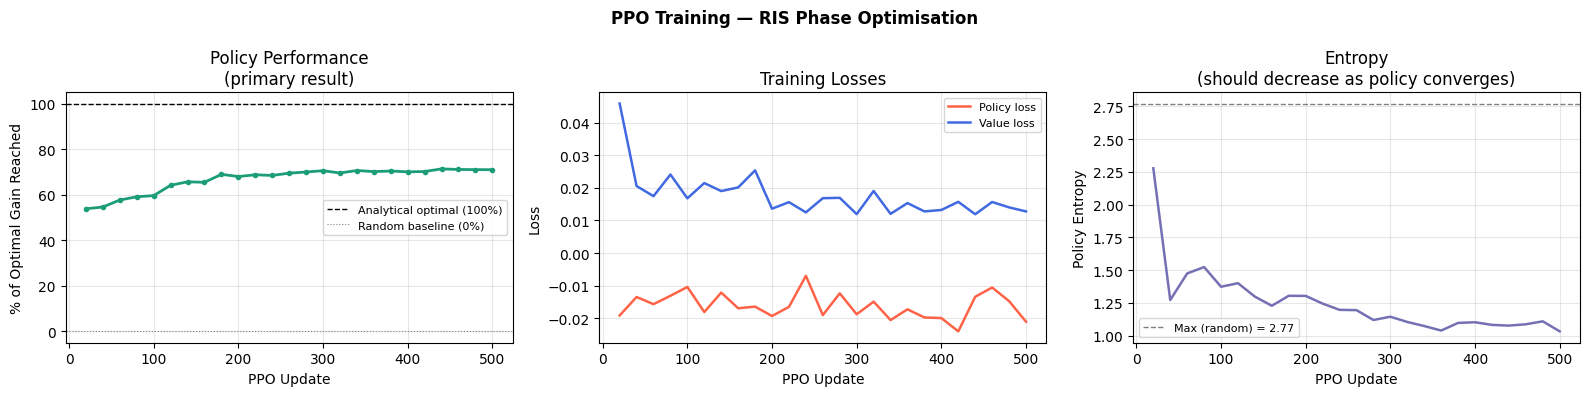


───────────────────────────────────────────────────────
Step-by-step episode — trained PPO (greedy)
───────────────────────────────────────────────────────
RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

  Initial gain  : -129.36 dB
  Optimal gain  : -128.36 dB
  Random gain   : -151.58 dB

  Step   Group    Phase    Gain(dB)    Reward     %Opt
     1       0      22°     -128.98    0.0723    86.5%
     2       1      22°     -128.85    0.0282    89.3%
     3       2      45°     -129.34   -0.0970    79.6%
     4       3      45°     -130.27   -0.1544    64.2%
     5       0       0°     -131.15   -0.1178    52.4%
     6       1       0°     -131.67   -0.0605    46.3%
     7       2     315°     -131.46    0.0235    48.7%
     8       3     270°     -128.83    0.4088    89.6%

  Total reward  : 0.1031
  Final %opt    : 89.

In [ ]:
"""
PPO TRAINING LOOP — RIS PHASE OPTIMISATION
============================================
Block 4 of 4. Run after Blocks 1, 2, 3.

Training loop:
  - Collect ROLLOUT_STEPS transitions from environment
  - Run PPO update on collected rollout
  - Repeat for N_UPDATES updates
  - Log and evaluate every LOG_EVERY updates

Key metric: % of optimal gain reached at end of episode
Target: PPO agent reaches 85-95% of analytical optimal
"""

import numpy as np
import torch
import time
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════
# TRAINING CONFIG
# ═══════════════════════════════════════════════════════════════════

N_UPDATES     = 500       # total PPO updates
LOG_EVERY     = 20        # evaluate + print every N updates
EVAL_EPISODES = 200       # episodes per evaluation
EVAL_SEED     = 999       # fixed seed for consistent evaluation

# Steps per update = ROLLOUT_STEPS (512, set in agent block)
# Episodes per update ≈ ROLLOUT_STEPS / T = 512 / 8 = 64
# Total env steps = N_UPDATES × ROLLOUT_STEPS = 256,000

print(f"Training Config")
print(f"  Updates        : {N_UPDATES}")
print(f"  Steps/update   : {ROLLOUT_STEPS}")
print(f"  Total steps    : {N_UPDATES * ROLLOUT_STEPS:,}")
print(f"  Eval episodes  : {EVAL_EPISODES}")
print(f"  Log every      : {LOG_EVERY} updates\n")

# ═══════════════════════════════════════════════════════════════════
# EVALUATION
# ═══════════════════════════════════════════════════════════════════

def evaluate(n_episodes=EVAL_EPISODES, seed=EVAL_SEED):
    """
    Run n_episodes with greedy policy (argmax logits).
    Returns mean episode reward and mean % of optimal reached.
    """
    eval_env = RISEnv(seed=seed)
    ac.eval()
    ep_rewards = []
    ep_pct_opt = []

    with torch.no_grad():
        for _ in range(n_episodes):
            state     = eval_env.reset()
            ep_reward = 0.0
            for _ in range(T):
                s_t    = torch.FloatTensor(state).unsqueeze(0).to(device)
                logits, _ = ac(s_t)
                action = logits.argmax(dim=1).item()   # greedy
                state, reward, done, info = eval_env.step(action)
                ep_reward += reward
            ep_rewards.append(ep_reward)
            ep_pct_opt.append(info['pct_optimal'])

    ac.train()
    return float(np.mean(ep_rewards)), float(np.mean(ep_pct_opt))


# ═══════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════

history = {
    'update'      : [],
    'eval_reward' : [],
    'pct_optimal' : [],
    'policy_loss' : [],
    'value_loss'  : [],
    'entropy'     : [],
}

train_env = RISEnv(seed=TRAIN_SEED)
state     = train_env.reset()
buffer.reset()

t_start   = time.time()

print(f"{'─'*70}")
print(f"{'Update':>7}  {'Steps':>8}  {'EvalR':>7}  {'%Opt':>7}  "
      f"{'PiLoss':>8}  {'ValLoss':>8}  {'Entropy':>8}  {'Time':>6}")
print(f"{'─'*70}")

for update in range(1, N_UPDATES + 1):

    # ── Collect rollout ──────────────────────────────────────────────
    buffer.reset()
    ac.train()

    for _ in range(ROLLOUT_STEPS):
        s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action, log_prob, value, _ = ac.act(s_t)

        a  = action.item()
        lp = log_prob.item()
        v  = value.item()

        next_state, reward, done, _ = train_env.step(a)
        buffer.store(state, a, reward, v, lp, float(done))

        state = train_env.reset() if done else next_state

    # Bootstrap final value
    with torch.no_grad():
        s_t       = torch.FloatTensor(state).unsqueeze(0).to(device)
        _, last_v, _, _ = ac.act(s_t)
        last_value = last_v.item()

    # ── PPO update ───────────────────────────────────────────────────
    metrics = ppo_update(ac, optimiser, buffer, last_value)

    # ── Log ──────────────────────────────────────────────────────────
    if update % LOG_EVERY == 0:
        eval_r, pct_opt = evaluate()
        elapsed = time.time() - t_start

        history['update'].append(update)
        history['eval_reward'].append(eval_r)
        history['pct_optimal'].append(pct_opt)
        history['policy_loss'].append(metrics['policy_loss'])
        history['value_loss'].append(metrics['value_loss'])
        history['entropy'].append(metrics['entropy'])

        print(f"{update:>7}  "
              f"{update*ROLLOUT_STEPS:>8,}  "
              f"{eval_r:>7.3f}  "
              f"{pct_opt:>6.1f}%  "
              f"{metrics['policy_loss']:>8.4f}  "
              f"{metrics['value_loss']:>8.4f}  "
              f"{metrics['entropy']:>8.4f}  "
              f"{elapsed:>5.0f}s")

print(f"{'─'*70}")
print(f"\nTraining complete.")
print(f"  Final %optimal : {history['pct_optimal'][-1]:.1f}%")
print(f"  Final reward   : {history['eval_reward'][-1]:.4f}")

# ═══════════════════════════════════════════════════════════════════
# CONVERGENCE PLOT
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("PPO Training — RIS Phase Optimisation",
             fontsize=12, fontweight='bold')

updates = history['update']

# % Optimal — primary result
axes[0].plot(updates, history['pct_optimal'],
             color='#1b9e77', lw=2.0, marker='o', markersize=3)
axes[0].axhline(100, color='black', linestyle='--', lw=1.0,
                label='Analytical optimal (100%)')
axes[0].axhline(0,   color='gray',  linestyle=':',  lw=0.8,
                label='Random baseline (0%)')
axes[0].set_xlabel('PPO Update')
axes[0].set_ylabel('% of Optimal Gain Reached')
axes[0].set_title('Policy Performance\n(primary result)')
axes[0].set_ylim(-5, 105)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Losses
axes[1].plot(updates, history['policy_loss'],
             color='tomato', lw=1.8, label='Policy loss')
axes[1].plot(updates, history['value_loss'],
             color='royalblue', lw=1.8, label='Value loss')
axes[1].set_xlabel('PPO Update')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Losses')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Entropy — should decrease as policy becomes more confident
axes[2].plot(updates, history['entropy'],
             color='#7570b3', lw=1.8)
axes[2].axhline(np.log(n_actions), color='gray', linestyle='--',
                lw=1.0, label=f'Max (random) = {np.log(n_actions):.2f}')
axes[2].set_xlabel('PPO Update')
axes[2].set_ylabel('Policy Entropy')
axes[2].set_title('Entropy\n(should decrease as policy converges)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/ppo_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════
# STEP-BY-STEP CONVERGENCE — one sample episode
# ═══════════════════════════════════════════════════════════════════

print(f"\n{'─'*55}")
print(f"Step-by-step episode — trained PPO (greedy)")
print(f"{'─'*55}")

vis_env = RISEnv(seed=77)
state   = vis_env.reset()
ac.eval()

print(f"  Initial gain  : {10*np.log10(vis_env.gain_prev):.2f} dB")
print(f"  Optimal gain  : {10*np.log10(vis_env.gain_opt):.2f} dB")
print(f"  Random gain   : {10*np.log10(vis_env.gain_rand):.2f} dB\n")
print(f"  {'Step':>4}  {'Group':>6}  {'Phase':>7}  "
      f"{'Gain(dB)':>10}  {'Reward':>8}  {'%Opt':>7}")

ep_r = 0
with torch.no_grad():
    for _ in range(T):
        s_t    = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits, _ = ac(s_t)
        action = logits.argmax(dim=1).item()
        state, reward, done, info = vis_env.step(action)
        ep_r  += reward
        print(f"  {info['step']:>4}  {info['group']:>6}  "
              f"{info['phase_deg']:>6.0f}°  "
              f"{info['gain_db']:>10.2f}  "
              f"{reward:>8.4f}  "
              f"{info['pct_optimal']:>6.1f}%")

print(f"\n  Total reward  : {ep_r:.4f}")
print(f"  Final %opt    : {info['pct_optimal']:.1f}%")
print(f"  Gain gap      : {info['gain_opt_db'] - info['gain_db']:.2f} dB "
      f"below optimal")

# ═══════════════════════════════════════════════════════════════════
# SAVE MODEL
# ═══════════════════════════════════════════════════════════════════

torch.save({
    'ac_state_dict'       : ac.state_dict(),
    'optimiser_state_dict': optimiser.state_dict(),
    'history'             : history,
    'hyperparams': {
        'hidden_dim'   : HIDDEN_DIM,
        'n_layers'     : N_LAYERS,
        'lr'           : LR,
        'gamma'        : GAMMA,
        'gae_lambda'   : GAE_LAMBDA,
        'clip_eps'     : CLIP_EPS,
        'entropy_coef' : ENTROPY_COEF,
        'value_coef'   : VALUE_COEF,
        'rollout_steps': ROLLOUT_STEPS,
        'n_updates'    : N_UPDATES,
        'state_dim'    : state_dim,
        'n_actions'    : n_actions,
    }
}, '/content/ppo_model.pt')

print(f"\nModel saved → /content/ppo_model.pt")
print(f"Plot  saved → /content/ppo_training.png")

In [ ]:
"""
PRINT BLOCK (Improved) — PPO phase values after training + ceiling comparison
===========================================================================
Run after Blocks 1–4.

What it prints:
  - PPO group phases (degrees)
  - Final %Opt for that episode
  - Discrete ceiling %Opt for the SAME geometry (best possible with G groups, K levels)
  - PPO vs ceiling (%)
  - Per-group phase error vs ceiling (degrees)
  - 16×16 phase map (group-tied)
  - Optional full 256-element table (toggle PRINT_ALL_ELEMENTS)
"""

import numpy as np
import torch

# -----------------------------
# User settings
# -----------------------------
SEED = 999              # pick 999 (or any) to get a reproducible demo geometry
PRINT_ALL_ELEMENTS = False  # set True if you really want the 256-row dump

# -----------------------------
# Patch reset to expose tau_opt (ideal per-element delays)
# -----------------------------
def patched_reset(self):
    tx, rx = self._sample_geometry()
    (self.tau_na, self.tau_nb,
     self.alpha_ch, self.beta_ch,
     self.tau_opt,
     self.phi_opt_deg,
     self.gain_opt) = compute_channel(tx, rx)

    self.gain_rand = random_gain(
        self.tau_na, self.tau_nb,
        self.alpha_ch, self.beta_ch,
        self.rng, n_samples=20
    )

    self.group_phases = np.zeros(G, dtype=int)
    self.gain_prev    = self._gain(phase_levels_deg[self.group_phases])
    self.step_count   = 0
    return self._get_state()

RISEnv.reset = patched_reset


# -----------------------------
# Discrete ceiling (best achievable with grouping + K-level quantization)
# -----------------------------
def compute_discrete_ceiling(env_obj):
    """
    For the current geometry in env_obj (i.e., after reset()),
    compute best group phases by circular-mean of per-element optimal phases,
    snapped to nearest of K discrete phase levels.

    Returns:
      pct_ceiling (float)
      ceiling_group_phases_deg (np.ndarray shape (G,))
      ceiling_group_phases_k (np.ndarray shape (G,), indices 0..K-1)
    """
    ceiling_k = []

    for g in range(G):
        idx = (element_group == g)

        # Convert ideal per-element delay -> ideal per-element phase in degrees
        phi_deg = (np.rad2deg(2 * np.pi * fc * env_obj.tau_opt[idx])) % 360

        # Circular mean (proper mean for angles)
        mean_ph = (np.rad2deg(np.angle(np.mean(np.exp(1j * np.deg2rad(phi_deg)))))) % 360

        # Snap to nearest discrete phase level
        diffs = np.abs(((phase_levels_deg - mean_ph + 180) % 360) - 180)
        best_k = int(np.argmin(diffs))
        ceiling_k.append(best_k)

    ceiling_k = np.array(ceiling_k, dtype=int)
    saved = env_obj.group_phases.copy()

    env_obj.group_phases = ceiling_k.copy()
    gain_ceiling = env_obj._gain(phase_levels_deg[env_obj.group_phases])

    pct_ceiling = (gain_ceiling - env_obj.gain_rand) / (env_obj.gain_opt - env_obj.gain_rand + 1e-20) * 100.0
    env_obj.group_phases = saved

    return float(pct_ceiling), phase_levels_deg[ceiling_k], ceiling_k


# -----------------------------
# Run one PPO greedy episode (after training)
# -----------------------------
print_env = RISEnv(seed=SEED)
state = print_env.reset()
ac.eval()

with torch.no_grad():
    for _ in range(T):
        s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits, _ = ac(s_t)
        action = logits.argmax(dim=1).item()
        state, _, done, info = print_env.step(action)

ppo_group_phases_k   = print_env.group_phases.copy()
ppo_group_phases_deg = phase_levels_deg[ppo_group_phases_k]

# Compute ceiling on the SAME geometry
pct_ceiling, ceil_group_phases_deg, ceil_group_phases_k = compute_discrete_ceiling(print_env)

# Phase error vs ceiling (wrap-around)
phase_err = np.abs(ppo_group_phases_deg - ceil_group_phases_deg)
phase_err = np.minimum(phase_err, 360 - phase_err)

# Expand to per-element phase map for printing/visuals
ppo_element_phases_deg = np.zeros(N, dtype=np.float32)
for g in range(G):
    idx = (element_group == g)
    ppo_element_phases_deg[idx] = ppo_group_phases_deg[g]

phase_map = ppo_element_phases_deg.reshape(Ny, Nz)

# -----------------------------
# Print summary
# -----------------------------
print("=" * 80)
print(f"PPO Phase Summary (seed={SEED}, G={G} groups, K={K} levels, M={M} probes)")
print("-" * 80)
print(f"PPO group phase indices (k): {ppo_group_phases_k.tolist()}")
print(f"PPO group phase degrees    : {ppo_group_phases_deg.astype(float)}")
print(f"Episode %Opt (vs analytic) : {info['pct_optimal']:.1f}%")
print()
print(f"Discrete ceiling %Opt      : {pct_ceiling:.1f}%   (best possible under grouping+K)")
print(f"Ceiling group phases (deg) : {ceil_group_phases_deg.astype(float)}")
print(f"PPO / ceiling              : {info['pct_optimal'] / (pct_ceiling + 1e-20) * 100:.1f}%")
print(f"Phase error vs ceiling (°) : {phase_err.astype(float)}")
print("=" * 80)

# Compact view: 16×16 map
print("\nPPO per-element phase map (degrees) — 16×16 (group-tied):")
np.set_printoptions(precision=1, suppress=True)
print(phase_map)

# Optional: full 256-row dump
if PRINT_ALL_ELEMENTS:
    print("\n" + "=" * 80)
    print(f"Per-element phase assignments (all {N} elements)")
    print("=" * 80)
    print(f"  {'Elem':>6}  {'Row(y)':>7}  {'Col(z)':>7}  {'Group':>6}  {'Phase (°)':>10}")
    print(f"  {'─'*6}  {'─'*7}  {'─'*7}  {'─'*6}  {'─'*10}")
    for n in range(N):
        row = n // Nz
        col = n % Nz
        g   = element_group[n]
        print(f"  {n:>6}  {row:>7}  {col:>7}  {g:>6}  {ppo_element_phases_deg[n]:>9.2f}°")
    print("=" * 80)
    print(f"Unique phase values used: {np.unique(ppo_element_phases_deg)}")

RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

PPO Phase Summary (seed=999, G=4 groups, K=16 levels, M=4 probes)
--------------------------------------------------------------------------------
PPO group phase indices (k): [5, 7, 9, 10]
PPO group phase degrees    : [112.5 157.5 202.5 225. ]
Episode %Opt (vs analytic) : 44.6%

Discrete ceiling %Opt      : 46.4%   (best possible under grouping+K)
Ceiling group phases (deg) : [ 90.  135.  202.5 247.5]
PPO / ceiling              : 96.0%
Phase error vs ceiling (°) : [22.5 22.5  0.  22.5]

PPO per-element phase map (degrees) — 16×16 (group-tied):
[[112.5 112.5 112.5 112.5 157.5 157.5 157.5 157.5 202.5 202.5 202.5 202.5
  225.  225.  225.  225. ]
 [112.5 112.5 112.5 112.5 157.5 157.5 157.5 157.5 202.5 202.5 202.5 202.5
  225.  225.  225.  225. ]
 [112.5 112.5 112.5 112.5 157.5 15

EVALUATION — PPO RIS Phase Optimisation

────────────────────────────────────────────────────────────
SECTION 1 — Baseline Comparison  (200 episodes, seed=999)
────────────────────────────────────────────────────────────
RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/ep   : 8
  Noise      : 0.1
  Probes     : M=4 random per group per step

RISEnv  (v4 — partial observations, M=4/16 probes)
  State dim  : 41  (gains 16 + indices 16 + phase 8 + step 1)
  Actions    : 16
  Steps/e

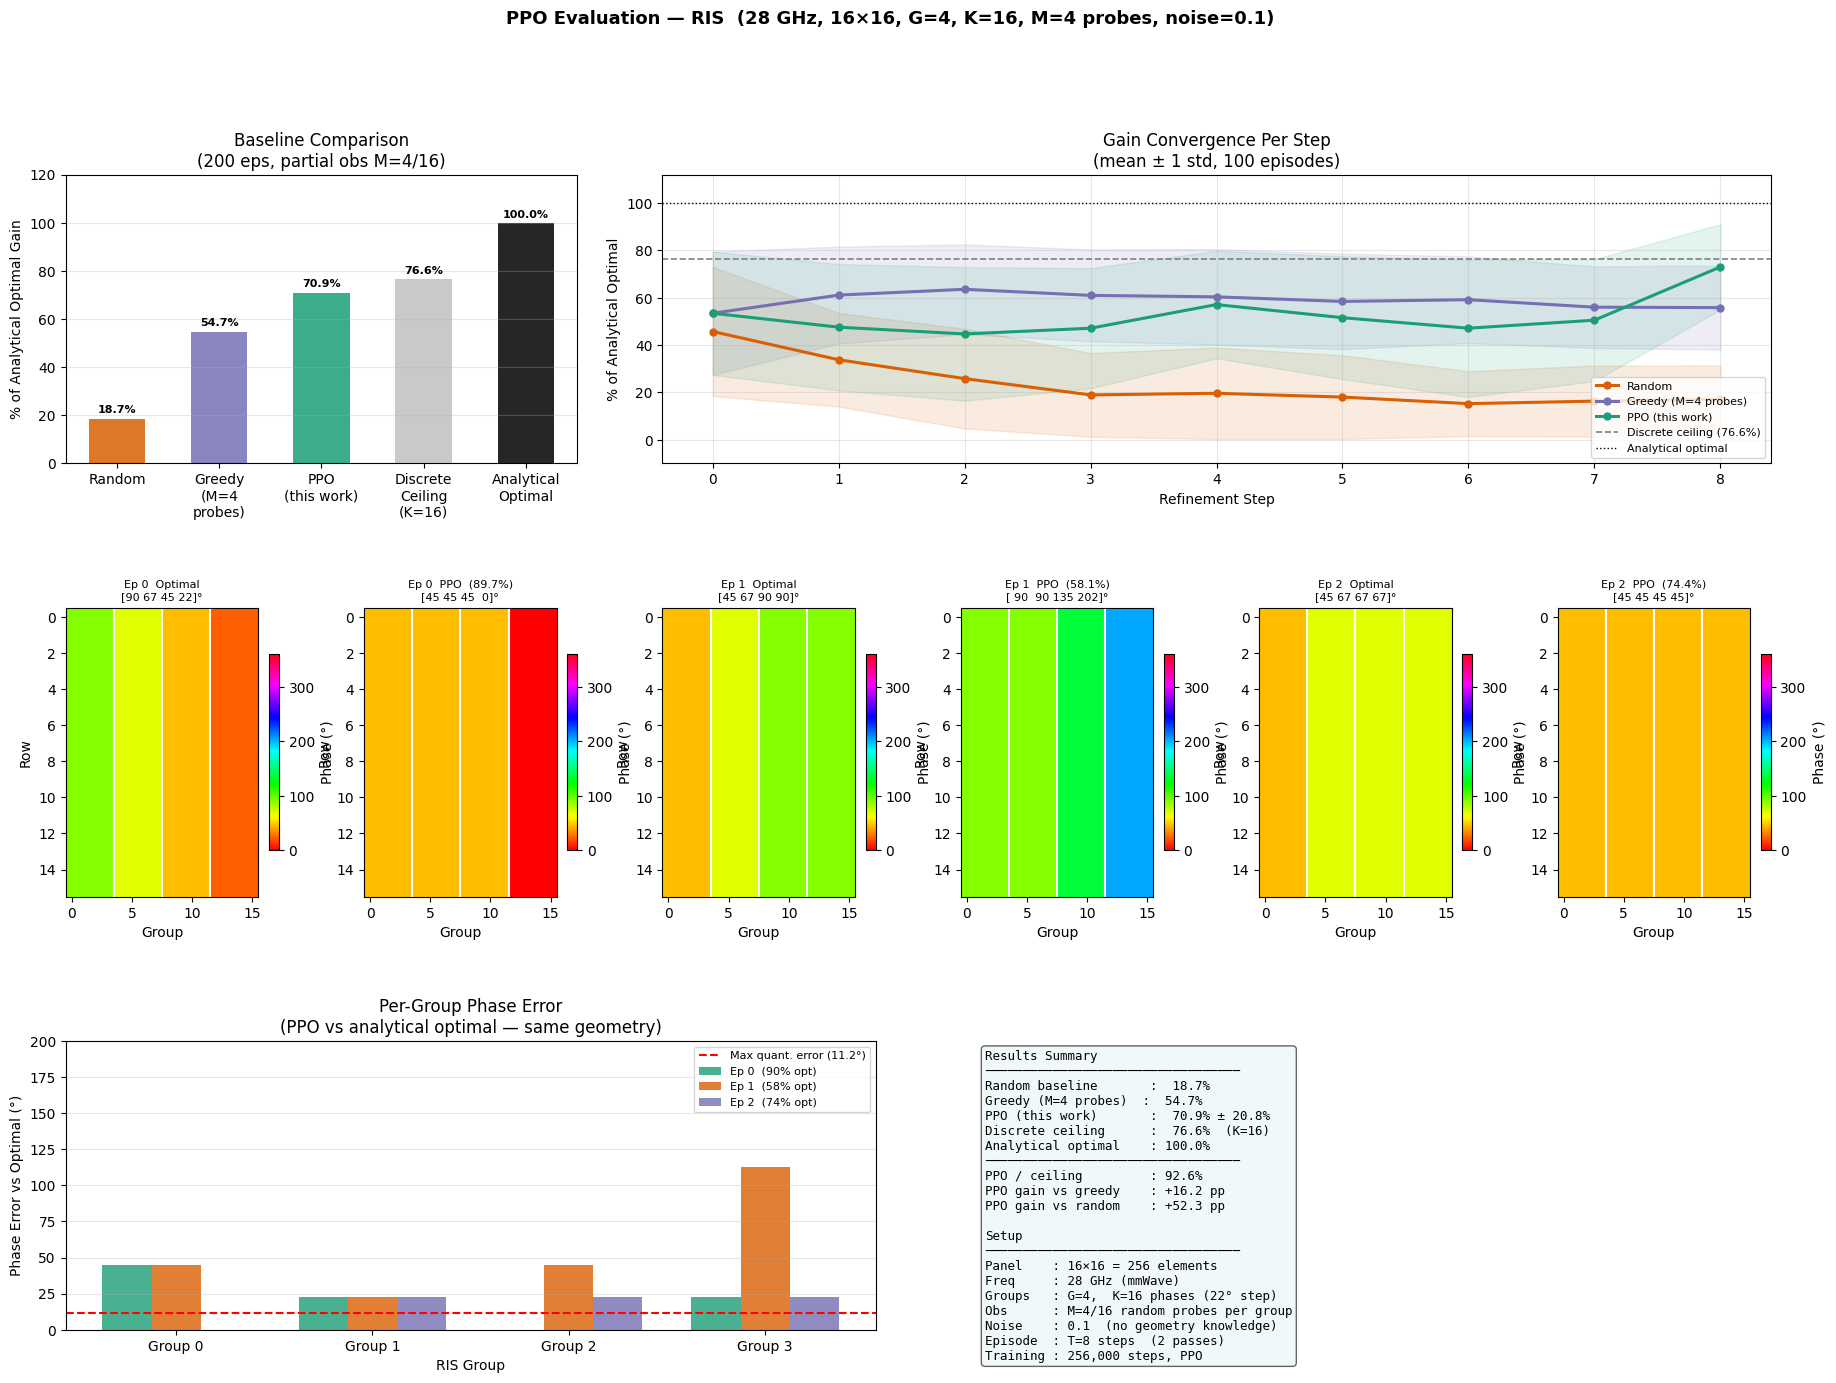


Evaluation complete.
  Plot → /content/ppo_evaluation.png


In [ ]:
"""
EVALUATION BLOCK — PPO RIS PHASE OPTIMISATION (v4 partial obs)
================================================================
Block 5. Run after Blocks 1–4.

Sections:
  1. Baseline comparison table
  2. Gain convergence per step
  3. Phase visualisation — PPO vs analytical optimal
  4. Per-group phase error
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("=" * 60)
print("EVALUATION — PPO RIS Phase Optimisation")
print("=" * 60)

# ── Patch RISEnv.reset to expose tau_opt ────────────────────────

def _patched_reset(self):
    tx, rx = self._sample_geometry()
    (self.tau_na, self.tau_nb,
     self.alpha_ch, self.beta_ch,
     self.tau_opt,
     self.phi_wrapped,
     self.gain_opt) = compute_channel(tx, rx)
    self.gain_rand = random_gain(
        self.tau_na, self.tau_nb,
        self.alpha_ch, self.beta_ch,
        self.rng, n_samples=20
    )
    self.group_phases = np.zeros(G, dtype=int)
    self.gain_prev    = self._gain(phase_levels_deg[self.group_phases])
    self.step_count   = 0
    return self._get_state()

RISEnv.reset = _patched_reset

ac.eval()

# ═══════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════

def greedy_action(state, current_group):
    """
    Greedy policy for v4 partial observations.
    Reads the M partial gains for current_group and picks
    the phase level with the highest measured gain.
    State layout: [gains M*G | indices M*G | sin G | cos G | step]
    """
    g         = current_group
    gains_g   = state[g * M : g * M + M]
    indices_g = state[G * M + g * M : G * M + g * M + M]
    best_i    = int(np.argmax(gains_g))
    best_k    = int(np.round(indices_g[best_i] * (K - 1)))
    return best_k


def run_episode(eval_env, policy='ppo'):
    """
    Run one full episode. Calls reset internally.
    policy: 'ppo' | 'greedy' | 'random'
    Returns: gains_db (T+1,), pct_optimal, gain_opt_db,
             gain_rand_db, final group_phases
    """
    state    = eval_env.reset()
    gains_db = [10 * np.log10(eval_env.gain_prev + 1e-20)]

    for _ in range(eval_env.T):
        if policy == 'ppo':
            with torch.no_grad():
                s_t    = torch.FloatTensor(state).unsqueeze(0).to(device)
                logits, _ = ac(s_t)
            action = logits.argmax(dim=1).item()
        elif policy == 'greedy':
            action = greedy_action(state, eval_env.current_group)
        else:
            action = int(eval_env.rng.integers(0, eval_env.n_actions))

        state, _, done, info = eval_env.step(action)
        gains_db.append(info['gain_db'])

    return (gains_db,
            info['pct_optimal'],
            info['gain_opt_db'],
            info['gain_rand_db'],
            eval_env.group_phases.copy())


def reset_to_zeros(eval_env):
    """Reset phases to zero without resampling geometry."""
    eval_env.group_phases = np.zeros(G, dtype=int)
    eval_env.gain_prev    = eval_env._gain(
        phase_levels_deg[eval_env.group_phases]
    )
    eval_env.step_count = 0


def compute_discrete_ceiling(eval_env):
    """
    Best achievable with K phase levels on the current geometry.
    Does not resample geometry.
    """
    best = []
    for g in range(G):
        idx     = (element_group == g)
        phi_deg = np.rad2deg(2*np.pi*fc*eval_env.tau_opt[idx]) % 360
        mean_ph = np.rad2deg(
            np.angle(np.mean(np.exp(1j * np.deg2rad(phi_deg))))
        ) % 360
        diffs   = np.abs(((phase_levels_deg - mean_ph + 180) % 360) - 180)
        best.append(int(np.argmin(diffs)))

    saved = eval_env.group_phases.copy()
    for g in range(G):
        eval_env.group_phases[g] = best[g]
    gain = eval_env._gain(phase_levels_deg[eval_env.group_phases])
    pct  = (gain - eval_env.gain_rand) / \
           (eval_env.gain_opt - eval_env.gain_rand + 1e-20) * 100
    eval_env.group_phases = saved
    return pct, phase_levels_deg[np.array(best)]


# ═══════════════════════════════════════════════════════════════════
# 1. BASELINE COMPARISON  (200 episodes)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "─"*60)
print("SECTION 1 — Baseline Comparison  (200 episodes, seed=999)")
print("─"*60)

N_EVAL    = 200
pct_all   = {p: [] for p in ['random', 'greedy', 'ppo']}
ceil_pcts = []

for policy in ['random', 'greedy', 'ppo']:
    ev = RISEnv(seed=999)
    for _ in range(N_EVAL):
        _, pct, _, _, _ = run_episode(ev, policy)
        pct_all[policy].append(pct)

ceil_env = RISEnv(seed=999)
for _ in range(N_EVAL):
    ceil_env.reset()
    pct_c, _ = compute_discrete_ceiling(ceil_env)
    ceil_pcts.append(pct_c)

ceil_mean = np.mean(ceil_pcts)
stats     = {p: (np.mean(pct_all[p]), np.std(pct_all[p]))
             for p in pct_all}

print(f"\n  {'Method':<26}  {'Mean %Opt':>10}  {'Std':>8}")
print(f"  {'─'*26}  {'─'*10}  {'─'*8}")
for label, key in [('Random baseline',      'random'),
                   ('Greedy (partial obs)', 'greedy'),
                   ('PPO (this work)',       'ppo')]:
    m, s = stats[key]
    print(f"  {label:<26}  {m:>9.1f}%  {s:>7.1f}%")
print(f"  {'─'*26}  {'─'*10}  {'─'*8}")
print(f"  {'Discrete ceiling (K='+str(K)+')':<26}  "
      f"{ceil_mean:>9.1f}%  {'—':>8}")
print(f"  {'Analytical optimal':<26}  {'100.0%':>10}  {'—':>8}")

ppo_m, ppo_s = stats['ppo']
greedy_m, _  = stats['greedy']
random_m, _  = stats['random']
ppo_vs_ceil  = ppo_m / ceil_mean * 100
print(f"\n  PPO vs discrete ceiling : {ppo_vs_ceil:.1f}% of ceiling")
print(f"  PPO gain over greedy    : {ppo_m - greedy_m:+.1f} pp")
print(f"  PPO gain over random    : {ppo_m - random_m:+.1f} pp")


# ═══════════════════════════════════════════════════════════════════
# 2. GAIN CONVERGENCE PER STEP  (100 episodes)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "─"*60)
print("SECTION 2 — Gain Convergence Per Step  (100 episodes)")
print("─"*60)

N_CONV = 100
conv   = {p: np.zeros((N_CONV, T+1)) for p in ['random', 'greedy', 'ppo']}

for policy in ['random', 'greedy', 'ppo']:
    ev = RISEnv(seed=777)
    for ep in range(N_CONV):
        gains_db, _, g_opt, g_rand, _ = run_episode(ev, policy)
        opt_lin  = 10**(g_opt  / 10)
        rand_lin = 10**(g_rand / 10)
        conv[policy][ep] = [
            (10**(g/10) - rand_lin) / (opt_lin - rand_lin + 1e-20) * 100
            for g in gains_db
        ]

print(f"\n  {'Policy':<10}  {'Step0':>6}  {'Step2':>6}  "
      f"{'Step4':>6}  {'Step6':>6}  {'Step8':>6}")
for p in ['random', 'greedy', 'ppo']:
    mn = conv[p].mean(axis=0)
    print(f"  {p:<10}  {mn[0]:>5.1f}%  {mn[2]:>5.1f}%  "
          f"{mn[4]:>5.1f}%  {mn[6]:>5.1f}%  {mn[8]:>5.1f}%")


# ═══════════════════════════════════════════════════════════════════
# 3. PHASE VISUALISATION  (3 sample episodes)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "─"*60)
print("SECTION 3 — Phase Visualisation  (3 sample episodes)")
print("─"*60)

vis_episodes = []
vis_env      = RISEnv(seed=77)

for ep_i in range(3):
    # One reset → fix geometry for this episode
    vis_env.reset()

    # Compute ceiling on this geometry
    _, opt_phases_deg = compute_discrete_ceiling(vis_env)

    # Run PPO on SAME geometry (reset_to_zeros keeps channel params)
    reset_to_zeros(vis_env)
    state = vis_env._get_state()
    for _ in range(T):
        with torch.no_grad():
            s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            logits, _ = ac(s_t)
        action = logits.argmax(dim=1).item()
        state, _, done, info = vis_env.step(action)

    ppo_phases_deg = phase_levels_deg[vis_env.group_phases]

    opt_map = np.zeros(N)
    ppo_map = np.zeros(N)
    for g in range(G):
        idx          = (element_group == g)
        opt_map[idx] = opt_phases_deg[g]
        ppo_map[idx] = ppo_phases_deg[g]

    phase_errors = np.abs(opt_phases_deg - ppo_phases_deg)
    phase_errors = np.minimum(phase_errors, 360 - phase_errors)

    gain_ppo = vis_env._gain(ppo_phases_deg)
    pct_opt  = (gain_ppo - vis_env.gain_rand) / \
               (vis_env.gain_opt - vis_env.gain_rand + 1e-20) * 100

    vis_episodes.append({
        'opt_map'   : opt_map.reshape(Ny, Nz),
        'ppo_map'   : ppo_map.reshape(Ny, Nz),
        'opt_phases': opt_phases_deg,
        'ppo_phases': ppo_phases_deg,
        'errors'    : phase_errors,
        'pct_opt'   : pct_opt,
    })

    print(f"  ep {ep_i}  "
          f"opt={opt_phases_deg.astype(int)}°  "
          f"ppo={ppo_phases_deg.astype(int)}°  "
          f"err={np.round(phase_errors,0).astype(int)}°  "
          f"%opt={pct_opt:.1f}%")


# ═══════════════════════════════════════════════════════════════════
# PLOTS
# ═══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 15))
fig.suptitle(
    f"PPO Evaluation — RIS  (28 GHz, {Ny}×{Nz}, G={G}, "
    f"K={K}, M={M} probes, noise={env.NOISE_LEVEL})",
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.50, wspace=0.40)

# ── Row 0: bar chart + convergence ──────────────────────────────

ax_bar = fig.add_subplot(gs[0, :2])
labels_bar = ['Random', f'Greedy\n(M={M}\nprobes)',
               'PPO\n(this work)',
               f'Discrete\nCeiling\n(K={K})', 'Analytical\nOptimal']
vals_bar   = [random_m, greedy_m, ppo_m, ceil_mean, 100.0]
cols_bar   = ['#d95f02', '#7570b3', '#1b9e77', 'silver', 'black']
bars = ax_bar.bar(labels_bar, vals_bar, color=cols_bar,
                  alpha=0.85, width=0.55)
for bar, val in zip(bars, vals_bar):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
ax_bar.set_ylabel('% of Analytical Optimal Gain')
ax_bar.set_title(f'Baseline Comparison\n'
                 f'(200 eps, partial obs M={M}/{K})')
ax_bar.set_ylim(0, 120)
ax_bar.grid(True, alpha=0.3, axis='y')

ax_conv = fig.add_subplot(gs[0, 2:])
step_ax = np.arange(T + 1)
c_map   = {'random': '#d95f02', 'greedy': '#7570b3', 'ppo': '#1b9e77'}
l_map   = {'random': 'Random',
           'greedy': f'Greedy (M={M} probes)',
           'ppo'   : 'PPO (this work)'}
for p in ['random', 'greedy', 'ppo']:
    mn  = conv[p].mean(axis=0)
    std = conv[p].std(axis=0)
    ax_conv.plot(step_ax, mn, color=c_map[p], lw=2.2,
                 label=l_map[p], marker='o', markersize=5)
    ax_conv.fill_between(step_ax, mn-std, mn+std,
                         alpha=0.12, color=c_map[p])
ax_conv.axhline(ceil_mean, color='gray', linestyle='--', lw=1.2,
                label=f'Discrete ceiling ({ceil_mean:.1f}%)')
ax_conv.axhline(100, color='black', linestyle=':', lw=1.0,
                label='Analytical optimal')
ax_conv.set_xlabel('Refinement Step')
ax_conv.set_ylabel('% of Analytical Optimal')
ax_conv.set_title('Gain Convergence Per Step\n(mean ± 1 std, 100 episodes)')
ax_conv.legend(fontsize=8, loc='lower right')
ax_conv.grid(True, alpha=0.3)
ax_conv.set_xticks(step_ax)
ax_conv.set_ylim(-10, 112)

# ── Row 1: Phase heatmaps ────────────────────────────────────────

for ep_i, ep in enumerate(vis_episodes):
    ax_opt = fig.add_subplot(gs[1, ep_i * 2])
    im1 = ax_opt.imshow(ep['opt_map'], cmap='hsv',
                        vmin=0, vmax=360, aspect='auto')
    ax_opt.set_title(
        f'Ep {ep_i}  Optimal\n{ep["opt_phases"].astype(int)}°',
        fontsize=8)
    ax_opt.set_xlabel('Group')
    ax_opt.set_ylabel('Row')
    for g in range(1, G):
        ax_opt.axvline(g*(Nz//G) - 0.5, color='white', lw=1.5)
    plt.colorbar(im1, ax=ax_opt, label='Phase (°)', fraction=0.046)

    ax_ppo = fig.add_subplot(gs[1, ep_i * 2 + 1])
    im2 = ax_ppo.imshow(ep['ppo_map'], cmap='hsv',
                        vmin=0, vmax=360, aspect='auto')
    ax_ppo.set_title(
        f'Ep {ep_i}  PPO  ({ep["pct_opt"]:.1f}%)\n'
        f'{ep["ppo_phases"].astype(int)}°',
        fontsize=8)
    ax_ppo.set_xlabel('Group')
    ax_ppo.set_ylabel('Row')
    for g in range(1, G):
        ax_ppo.axvline(g*(Nz//G) - 0.5, color='white', lw=1.5)
    plt.colorbar(im2, ax=ax_ppo, label='Phase (°)', fraction=0.046)

# ── Row 2: Phase error + summary ────────────────────────────────

ax_err = fig.add_subplot(gs[2, :3])
x      = np.arange(G)
width  = 0.25
ep_colors = ['#1b9e77', '#d95f02', '#7570b3']
for ep_i, ep in enumerate(vis_episodes):
    ax_err.bar(x + ep_i * width, ep['errors'], width,
               label=f'Ep {ep_i}  ({ep["pct_opt"]:.0f}% opt)',
               color=ep_colors[ep_i], alpha=0.8)
ax_err.axhline(180/K, color='red', linestyle='--', lw=1.5,
               label=f'Max quant. error ({180/K:.1f}°)')
ax_err.set_xlabel('RIS Group')
ax_err.set_ylabel('Phase Error vs Optimal (°)')
ax_err.set_title('Per-Group Phase Error\n'
                 '(PPO vs analytical optimal — same geometry)')
ax_err.set_xticks(x + width)
ax_err.set_xticklabels([f'Group {g}' for g in range(G)])
ax_err.legend(fontsize=8)
ax_err.grid(True, alpha=0.3, axis='y')
ax_err.set_ylim(0, 200)

# Summary text box
ax_txt = fig.add_subplot(gs[2, 3:])
ax_txt.axis('off')
summary = (
    f"Results Summary\n"
    f"{'─'*34}\n"
    f"Random baseline       : {random_m:>5.1f}%\n"
    f"Greedy (M={M} probes)  : {greedy_m:>5.1f}%\n"
    f"PPO (this work)       : {ppo_m:>5.1f}% ± {ppo_s:.1f}%\n"
    f"Discrete ceiling      : {ceil_mean:>5.1f}%  (K={K})\n"
    f"Analytical optimal    : 100.0%\n"
    f"{'─'*34}\n"
    f"PPO / ceiling         : {ppo_vs_ceil:.1f}%\n"
    f"PPO gain vs greedy    : {ppo_m-greedy_m:+.1f} pp\n"
    f"PPO gain vs random    : {ppo_m-random_m:+.1f} pp\n\n"
    f"Setup\n"
    f"{'─'*34}\n"
    f"Panel    : {Ny}×{Nz} = {N} elements\n"
    f"Freq     : {fc/1e9:.0f} GHz (mmWave)\n"
    f"Groups   : G={G},  K={K} phases ({360//K}° step)\n"
    f"Obs      : M={M}/{K} random probes per group\n"
    f"Noise    : {env.NOISE_LEVEL}  (no geometry knowledge)\n"
    f"Episode  : T={T} steps  ({N_PASSES} passes)\n"
    f"Training : {N_UPDATES*ROLLOUT_STEPS:,} steps, PPO"
)
ax_txt.text(0.03, 0.97, summary, transform=ax_txt.transAxes,
            fontsize=9, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#e8f4f8', alpha=0.6))

plt.savefig('/content/ppo_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEvaluation complete.")
print(f"  Plot → /content/ppo_evaluation.png")